<a href="https://colab.research.google.com/github/savinthie/Final_Year_Project_Final_project/blob/main/Benchmarking_with_a_new_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing of necessary libraries**

In [1]:
from tensorflow.keras.layers import Layer
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, Flatten, Dense, ReLU, Concatenate, MaxPooling1D,Dropout
from tensorflow.keras.optimizers import Adam
import joblib
import matplotlib.pyplot as plt
from keras.callbacks import EarlyStopping
import xgboost as xgb
from tensorflow.keras.regularizers import l2
from tqdm import tqdm
from google.colab import drive
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import pickle

**Data collection stage**

In [2]:
drive.mount('/content/drive')
original_household_dataset = pd.read_csv('/content/drive/MyDrive/FYP 2024 25/w1867427_Final Year Project Submissions/w1867427_Final Year Project Code Submission/Dataset/ScalabilityTesting.csv', header=1)

Mounted at /content/drive


**Data preprocessing stage**

In [3]:
# Data Preprocessing
original_household_dataset = original_household_dataset.fillna(0)
original_household_dataset.columns = [col.lower().replace(' ', '').replace('.', '') for col in original_household_dataset.columns]
cols_to_keep = ['stateabv', 'county', 'family', 'housing', 'food', 'transportation',
                'healthcare', 'othernecessities', 'childcare', 'taxes', 'total',
                'median_family_income', 'num_counties_in_st']
household_dataset = original_household_dataset[cols_to_keep].copy()

# Remove whitespace, dollar signs, and commas before converting to float
household_dataset['median_family_income'] = household_dataset['median_family_income'].str.replace(' ', '').str.replace('$', '').str.replace(',', '', regex=True).astype(float)

**Feature engineering stage**

In [4]:
household_dataset['median_family_income'] = household_dataset['median_family_income'].map(lambda x: x/12)
household_dataset['n_parents'] = household_dataset['family'].str.slice(0, 1).astype(int)
household_dataset['n_children'] = household_dataset['family'].str.slice(2, 3).astype(int)
household_dataset['n_members'] = household_dataset['n_parents'] + household_dataset['n_children']
household_dataset['financial_stability'] = household_dataset['median_family_income'] / household_dataset['total']
household_dataset["per_member_cost"] = household_dataset["total"] / household_dataset["n_members"]
household_dataset["child_expense_cost"] = household_dataset["per_member_cost"]*household_dataset["n_children"]
household_dataset["parent_expense_cost"] = household_dataset["per_member_cost"]*household_dataset["n_parents"]
household_dataset["other_expense_cost"] = household_dataset["total"] - (household_dataset["child_expense_cost"]+household_dataset["parent_expense_cost"])
# fixing the 0 child issue
household_dataset["zero_childcare_cost"] = household_dataset['n_children'].map(lambda x: 0 if x < 1 else 1)

In [5]:
# prompt: check if the features have NaN values and replace it with 0

# Check for NaN values in the features and replace with 0
for feature in household_dataset.columns:
  if household_dataset[feature].isnull().values.any():
    household_dataset[feature].fillna(0, inplace=True)


<ipython-input-5-d41145c890d2>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  household_dataset[feature].fillna(0, inplace=True)


**Feature scaling (An important data handling technique in the Neural networks)**

In [6]:
# Splitting the data
X = household_dataset[['total', 'median_family_income', 'num_counties_in_st', 'n_children', 'n_parents', 'n_members']+['per_member_cost','child_expense_cost','parent_expense_cost','other_expense_cost','zero_childcare_cost']].values
y_expenses = household_dataset[['housing', 'food', 'transportation', 'healthcare', 'othernecessities', 'childcare', 'taxes']].values

target_col_list = ['housing', 'food', 'transportation', 'healthcare', 'othernecessities', 'childcare', 'taxes']

# Scaling
scaler_X = MinMaxScaler()

# Load the X scaler
# scaler_X = joblib.load('scaler_X.pkl')

X_scaled = scaler_X.fit_transform(X)

scaler_y = MinMaxScaler()

# Load the y scaler
# scaler_y = joblib.load('scaler_y.pkl')
y_exp_scaled = scaler_y.fit_transform(y_expenses)


# Save the X scaler
joblib.dump(scaler_X, 'scaler_X.pkl')

# Save the y scaler
joblib.dump(scaler_y, 'scaler_y.pkl')

['scaler_y.pkl']

In [7]:
# this method is used to avoid the issue in the mape and smape value for the childcare expenses since the childcare expenses consist of 0 value where the smape and mape are sensitive of.
def replace_zeros_with_ones(a, b):
    # Iterate through both lists simultaneously
    for i in range(len(a)):
        # If both value is 0, replace both with 1
        if a[i] == 0 and b[i] == 0:
            a[i] = 1
            b[i] = 1
    return a, b

*This replace_zero_with_one function is used to handle the infinity values in the MAPE and SMAPE metrics int he Childcare expenses since the Childcare expense for the no child is 0*

In [8]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def calculateSmape(y_true, y_pred):
    y_true, y_pred = replace_zeros_with_ones(y_true, y_pred)
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape_value = np.mean(numerator / denominator) * 100
    return smape_value

In [9]:
# Cross-Validation Setup
kf = KFold(n_splits=5, shuffle=True, random_state=100)

# Metrics
def print_metrics(y_true, y_pred, task_name):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{task_name} - MSE: {mse:.4f}, R2: {r2:.4f}")



def regr_report(x, y):
    mae = round(mean_absolute_error(x, y), 4)
    r2 = round(r2_score(x, y), 4)
    mse = round(mean_squared_error(x, y), 4)
    rmse = round(np.sqrt(mean_squared_error(x, y)), 4)
    smape_score = calculateSmape(x, y)
    mape= round(mean_absolute_percentage_error(x, y), 4)
    return f'MAE: {mae}, R-Squared: {r2}, RMSE: {rmse}, MSE: {mse} ,smape: {smape_score}, mape: {mape}'

In [10]:
num_children_col = 3  # 4th position, 0-indexed
childcare_exp_col = target_col_list.index('childcare')  # Replace 'childcare_exp' with the actual target name

**Model selection stage**

# Primary research contribution

 **Implementation of the improved version of the novel hybrid model**

**1D CNN-MLP Hybrid model**

In [11]:
# L2 regularization strength (you can tune this value)
l2_strength = 0.01
# Hybrid Model Definition
def create_hybrid_model(input_shape, output_shape):
    input_layer = Input(shape=input_shape)
    # CNN part
    x = Conv1D(filters=8, kernel_size=3, padding='same', activation='relu')(input_layer)
    x = Flatten()(x)
    # MLP part
    x = Dense(128, activation='relu')(x)
    x = Dense(64, activation='relu')(x)
    # Multiple regression outputs
    output_layers = [Dense(1, activation='linear', name=f'target_{col}')(x) for col in target_col_list]

    model = Model(inputs=input_layer, outputs=output_layers)
    return model

In [12]:
global X_train_global, X_test_global, X_val_global
global y_train_global, y_test_global, y_val_global

Fold 1/5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 11, 1)          │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d (Conv1D)           │ (None, 11, 8)          │             32 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 88)             │              0 │ conv1d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 128)            │         11,392 │ flatten[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 64)             │          8,256 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dense_1[0][0]          │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dense_1[0][0]          │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_childcare (Dense)  │ (None, 1)              │             65 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_taxes (Dense)      │ (None, 1)              │             65 │ dense_1[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 20,135 (78.65 KB)

 Trainable params: 20,135 (78.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 0.1031 - target_childcare_loss: 0.0112 - target_food_loss: 0.0113 - target_healthcare_loss: 0.0272 - target_housing_loss: 0.0071 - target_othernecessities_loss: 0.0089 - target_taxes_loss: 0.0044 - target_transportation_loss: 0.0330 - val_loss: 0.0140 - val_target_childcare_loss: 0.0020 - val_target_food_loss: 5.1746e-04 - val_target_healthcare_loss: 0.0049 - val_target_housing_loss: 0.0014 - val_target_othernecessities_loss: 9.4528e-04 - val_target_taxes_loss: 5.5723e-04 - val_target_transportation_loss: 0.0035
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0136 - target_childcare_loss: 0.0018 - target_food_loss: 5.9440e-04 - target_healthcare_loss: 0.0051 - target_housing_loss: 0.0015 - target_othernecessities_loss: 9.7051e-04 - target_taxes_loss: 3.9530e-04 - target_transportation_loss: 0.0032 - val_loss: 0.0130 - val_target_childcare_loss: 0.0016 - val_target_food_loss: 4.9042e-04 - val_target_healthcare_

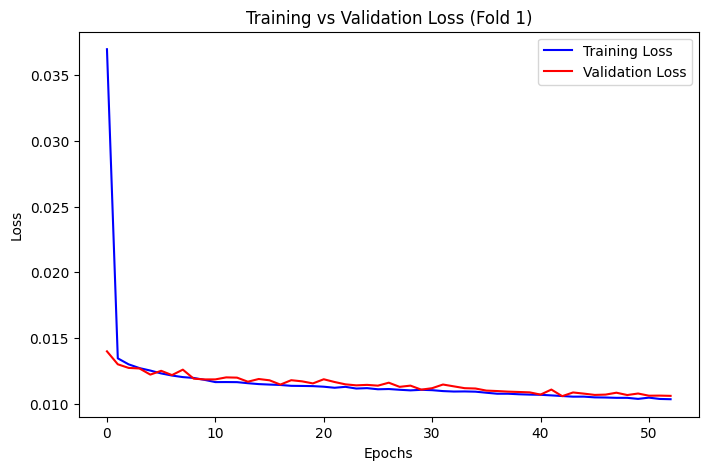

Fold 2/5


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 11, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_1 (Conv1D)         │ (None, 11, 8)          │             32 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_1 (Flatten)       │ (None, 88)             │              0 │ conv1d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 128)            │         11,392 │ flatten_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 64)             │          8,256 │ dense_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dense_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dense_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dense_3[0][0]          │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dense_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dense_3[0][0]          │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_childcare (Dense)  │ (None, 1)              │             65 │ dense_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_taxes (Dense)      │ (None, 1)              │             65 │ dense_3[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 20,135 (78.65 KB)

 Trainable params: 20,135 (78.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0693 - target_childcare_loss: 0.0114 - target_food_loss: 0.0049 - target_healthcare_loss: 0.0156 - target_housing_loss: 0.0066 - target_othernecessities_loss: 0.0048 - target_taxes_loss: 0.0022 - target_transportation_loss: 0.0237 - val_loss: 0.0139 - val_target_childcare_loss: 0.0018 - val_target_food_loss: 5.3384e-04 - val_target_healthcare_loss: 0.0052 - val_target_housing_loss: 0.0015 - val_target_othernecessities_loss: 0.0010 - val_target_taxes_loss: 4.0243e-04 - val_target_transportation_loss: 0.0034
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0130 - target_childcare_loss: 0.0017 - target_food_loss: 5.9613e-04 - target_healthcare_loss: 0.0049 - target_housing_loss: 0.0014 - target_othernecessities_loss: 9.2710e-04 - target_taxes_loss: 3.7313e-04 - target_transportation_loss: 0.0031 - val_loss: 0.0134 - val_target_childcare_loss: 0.0018 - val_target_food_loss: 5.6128e-04 - val_target_healthcare_loss:

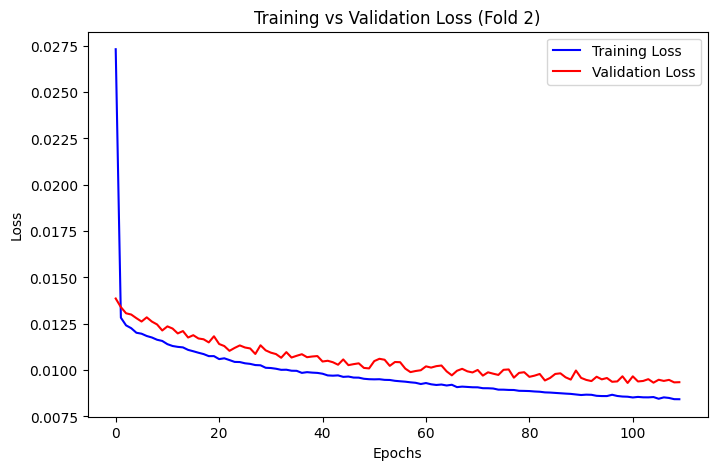

Fold 3/5


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 11, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_2 (Conv1D)         │ (None, 11, 8)          │             32 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_2 (Flatten)       │ (None, 88)             │              0 │ conv1d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (Dense)           │ (None, 128)            │         11,392 │ flatten_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_5 (Dense)           │ (None, 64)             │          8,256 │ dense_4[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dense_5[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dense_5[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dense_5[0][0]          │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dense_5[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dense_5[0][0]          │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_childcare (Dense)  │ (None, 1)              │             65 │ dense_5[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_taxes (Dense)      │ (None, 1)              │             65 │ dense_5[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 20,135 (78.65 KB)

 Trainable params: 20,135 (78.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0517 - target_childcare_loss: 0.0068 - target_food_loss: 0.0061 - target_healthcare_loss: 0.0148 - target_housing_loss: 0.0045 - target_othernecessities_loss: 0.0066 - target_taxes_loss: 0.0024 - target_transportation_loss: 0.0106 - val_loss: 0.0136 - val_target_childcare_loss: 0.0018 - val_target_food_loss: 7.6825e-04 - val_target_healthcare_loss: 0.0050 - val_target_housing_loss: 0.0013 - val_target_othernecessities_loss: 9.7915e-04 - val_target_taxes_loss: 3.3862e-04 - val_target_transportation_loss: 0.0033
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0130 - target_childcare_loss: 0.0018 - target_food_loss: 6.0793e-04 - target_healthcare_loss: 0.0048 - target_housing_loss: 0.0014 - target_othernecessities_loss: 9.4575e-04 - target_taxes_loss: 3.4983e-04 - target_transportation_loss: 0.0032 - val_loss: 0.0131 - val_target_childcare_loss: 0.0017 - val_target_food_loss: 7.1775e-04 - val_target_healthcare_l

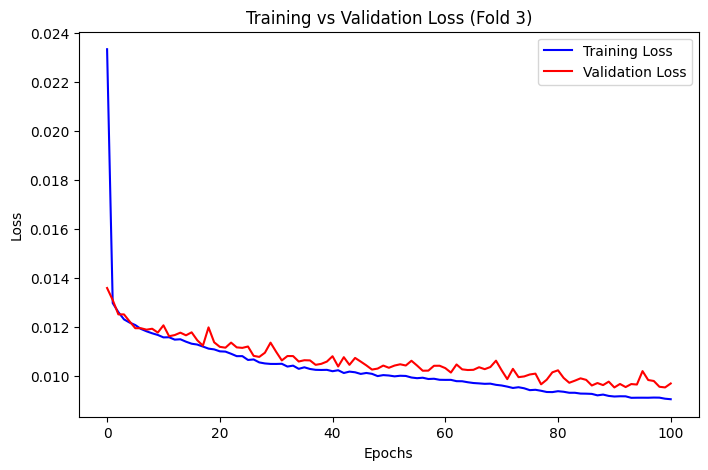

Fold 4/5


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 11, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_3 (Conv1D)         │ (None, 11, 8)          │             32 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_3 (Flatten)       │ (None, 88)             │              0 │ conv1d_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_6 (Dense)           │ (None, 128)            │         11,392 │ flatten_3[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_7 (Dense)           │ (None, 64)             │          8,256 │ dense_6[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dense_7[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dense_7[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dense_7[0][0]          │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dense_7[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dense_7[0][0]          │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_childcare (Dense)  │ (None, 1)              │             65 │ dense_7[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_taxes (Dense)      │ (None, 1)              │             65 │ dense_7[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 20,135 (78.65 KB)

 Trainable params: 20,135 (78.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0476 - target_childcare_loss: 0.0058 - target_food_loss: 0.0072 - target_healthcare_loss: 0.0119 - target_housing_loss: 0.0041 - target_othernecessities_loss: 0.0038 - target_taxes_loss: 0.0022 - target_transportation_loss: 0.0126 - val_loss: 0.0130 - val_target_childcare_loss: 0.0018 - val_target_food_loss: 5.6478e-04 - val_target_healthcare_loss: 0.0048 - val_target_housing_loss: 0.0013 - val_target_othernecessities_loss: 9.5133e-04 - val_target_taxes_loss: 3.8056e-04 - val_target_transportation_loss: 0.0031
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0132 - target_childcare_loss: 0.0017 - target_food_loss: 6.4636e-04 - target_healthcare_loss: 0.0049 - target_housing_loss: 0.0014 - target_othernecessities_loss: 9.7376e-04 - target_taxes_loss: 3.5004e-04 - target_transportation_loss: 0.0033 - val_loss: 0.0131 - val_target_childcare_loss: 0.0018 - val_target_food_loss: 5.9583e-04 - val_target_healthcare_l

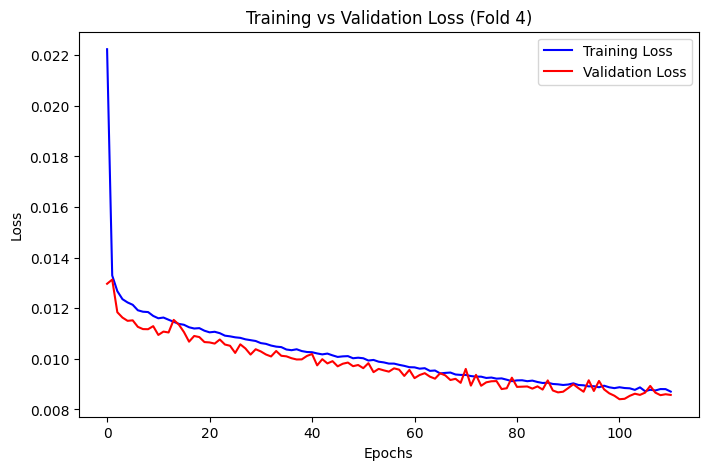

Fold 5/5


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 11, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_4 (Conv1D)         │ (None, 11, 8)          │             32 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_4 (Flatten)       │ (None, 88)             │              0 │ conv1d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_8 (Dense)           │ (None, 128)            │         11,392 │ flatten_4[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_9 (Dense)           │ (None, 64)             │          8,256 │ dense_8[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dense_9[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dense_9[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dense_9[0][0]          │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dense_9[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dense_9[0][0]          │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_childcare (Dense)  │ (None, 1)              │             65 │ dense_9[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_taxes (Dense)      │ (None, 1)              │             65 │ dense_9[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 20,135 (78.65 KB)

 Trainable params: 20,135 (78.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0694 - target_childcare_loss: 0.0059 - target_food_loss: 0.0101 - target_healthcare_loss: 0.0181 - target_housing_loss: 0.0050 - target_othernecessities_loss: 0.0060 - target_taxes_loss: 0.0050 - target_transportation_loss: 0.0192 - val_loss: 0.0130 - val_target_childcare_loss: 0.0016 - val_target_food_loss: 7.3327e-04 - val_target_healthcare_loss: 0.0049 - val_target_housing_loss: 0.0014 - val_target_othernecessities_loss: 9.5255e-04 - val_target_taxes_loss: 4.0290e-04 - val_target_transportation_loss: 0.0029
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0134 - target_childcare_loss: 0.0017 - target_food_loss: 6.2315e-04 - target_healthcare_loss: 0.0050 - target_housing_loss: 0.0015 - target_othernecessities_loss: 9.7509e-04 - target_taxes_loss: 3.6249e-04 - target_transportation_loss: 0.0033 - val_loss: 0.0128 - val_target_childcare_loss: 0.0018 - val_target_food_loss: 7.2196e-04 - val_target_healthcare_l

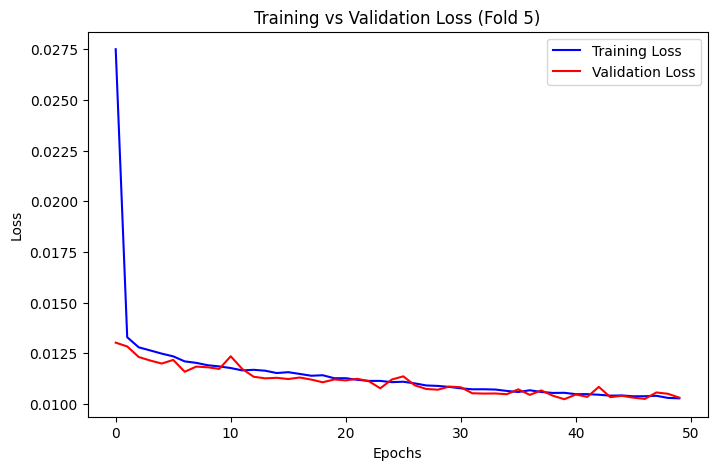

In [13]:
# Cross-Validation with Evaluation
def cross_val_with_evaluation(X_scaled, y_exp_scaled, kf, num_epochs=200):
    global X_train_global, X_test_global, X_val_global
    global y_train_global, y_test_global, y_val_global
    fold = 1
    for train_index, val_index in kf.split(X_scaled):
        print(f"Fold {fold}/{kf.get_n_splits()}")
        X_train, X_test_val = X_scaled[train_index], X_scaled[val_index]
        y_train, y_test_val = y_exp_scaled[train_index], y_exp_scaled[val_index]

        X_test, X_val, y_test, y_val = train_test_split(X_test_val, y_test_val, test_size=0.5, random_state=100) # 50/50 split of remaining 20%

        X_train_global, X_test_global, X_val_global = X_train, X_test, X_val
        y_train_global, y_test_global, y_val_global = y_train, y_test, y_val

        # Reshaping data for CNN
        X_train = X_train[..., np.newaxis]
        X_val = X_val[..., np.newaxis]
        X_test = X_test[..., np.newaxis]

        model = create_hybrid_model((X_train.shape[1], 1), y_train.shape[1])
        model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

        model.summary()

        early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

        # Training
        history = model.fit(X_train, [y_train[:, i] for i in range(y_train.shape[1])],
                  validation_data=(X_val, [y_val[:, i] for i in range(y_val.shape[1])]),
                  epochs=num_epochs, batch_size=64, verbose=1, callbacks= [early_stopping])

        # Predictions
        y_train_pred = np.column_stack(model.predict(X_train))
        y_val_pred = np.column_stack(model.predict(X_val))
        y_test_pred = np.column_stack(model.predict(X_test)) #Prediction on test set

        # Inverse scaling
        y_train_pred_original = scaler_y.inverse_transform(y_train_pred)
        y_train_original = scaler_y.inverse_transform(y_train)
        y_val_pred_original = scaler_y.inverse_transform(y_val_pred)
        y_val_original = scaler_y.inverse_transform(y_val)
        y_test_pred_original = scaler_y.inverse_transform(y_test_pred) #Inverse transform for test set
        y_test_original = scaler_y.inverse_transform(y_test) #Inverse transform for test set

        # Enforce the rule after predictions for childcare expense
        # The issue is likely caused by X_train having an extra dimension due to[..., np.newaxis].
        # We need to select the original features for the condition
        y_train_pred_original[:, childcare_exp_col] = np.where(
            X_train[:, num_children_col, 0] == 0, 0, y_train_pred_original[:, childcare_exp_col]) #Using X_train[:, num_children_col, 0] instead of X_train[:, num_children_col]

        y_val_pred_original[:, childcare_exp_col] = np.where(
            X_val[:, num_children_col, 0] == 0, 0, y_val_pred_original[:, childcare_exp_col]) #Using X_val[:, num_children_col, 0] instead of X_val[:, num_children_col]

        y_test_pred_original[:, childcare_exp_col] = np.where(
            X_test[:, num_children_col, 0] == 0, 0, y_test_pred_original[:, childcare_exp_col]) #Using X_test[:, num_children_col, 0] instead of X_test[:, num_children_col]

        # Metrics for each target
        for i, target in enumerate(target_col_list):
            print(f'Model Results for {target.capitalize()}:')
            print('Train Data:', regr_report(y_train_original[:, i], y_train_pred_original[:, i]))
            print('Validation Data:', regr_report(y_val_original[:, i], y_val_pred_original[:, i]))
            print('Test Data:', regr_report(y_test_original[:, i], y_test_pred_original[:, i])) #Print metrics for test set
            print()
        # Plot training and validation loss
        plt.figure(figsize=(8, 5))
        plt.plot(history.history['loss'], label='Training Loss', color='blue')
        plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title(f'Training vs Validation Loss (Fold {fold})')
        plt.legend()
        plt.show()

        fold += 1
    return model

model_combine = cross_val_with_evaluation(X_scaled, y_exp_scaled,kf)



**XGBoost**

In [14]:
# Cross-Validation with Evaluation for XGBoost
def cross_val_with_evaluation(X_scaled, y_exp_scaled, kf, num_boost_rounds=4000):
    fold = 1
    childcarelist = []
    childcarelist_pred = []
    for train_index, val_index in kf.split(X_scaled):
        models = []
        print(f"Fold {fold}/{kf.get_n_splits()}")
        X_train, X_test_val = X_scaled[train_index], X_scaled[val_index]
        y_train, y_test_val = y_exp_scaled[train_index], y_exp_scaled[val_index]

        # Split validation and test data
        X_test, X_val, y_test, y_val = train_test_split(
            X_test_val, y_test_val, test_size=0.5, random_state=100
        )  # 50/50 split of remaining 20%

        # Train XGBoost model for each target variable
        # Store predictions for all targets in this fold
        all_y_train_pred = []
        all_y_val_pred = []
        all_y_test_pred = []

        for i in range(y_train.shape[1]):
            dtrain = xgb.DMatrix(X_train, label=y_train[:, i])
            dval = xgb.DMatrix(X_val, label=y_val[:, i])
            dtest = xgb.DMatrix(X_test)

            params = {
                'objective': 'reg:squarederror',
                'eval_metric': 'rmse',
                'learning_rate': 0.01,
                'max_depth': 6,
                'n_estimators': num_boost_rounds
            }

            evals = [(dtrain, 'train'), (dval, 'eval')]
            model = xgb.train(
                params, dtrain, num_boost_rounds, evals, early_stopping_rounds=50, verbose_eval=50
            )
            models.append(model) #Not required here

            # Predictions
            y_train_pred = model.predict(dtrain)
            y_val_pred = model.predict(dval)
            y_test_pred = model.predict(dtest)

            # Append predictions for current target to the list
            all_y_train_pred.append(y_train_pred)
            all_y_val_pred.append(y_val_pred)
            all_y_test_pred.append(y_test_pred)

        # Stack predictions for all targets to get the original shape
        y_train_pred = np.column_stack(all_y_train_pred)
        y_val_pred = np.column_stack(all_y_val_pred)
        y_test_pred = np.column_stack(all_y_test_pred)

        # Inverse scaling
        y_train_pred_original = scaler_y.inverse_transform(y_train_pred) #Now y_train_pred has 7 columns matching scaler_y
        y_train_original = scaler_y.inverse_transform(y_train)
        y_val_pred_original = scaler_y.inverse_transform(y_val_pred)  #Now y_val_pred has 7 columns matching scaler_y
        y_val_original = scaler_y.inverse_transform(y_val)
        y_test_pred_original = scaler_y.inverse_transform(y_test_pred) #Now y_test_pred has 7 columns matching scaler_y
        y_test_original = scaler_y.inverse_transform(y_test)


        # Enforce the rule after predictions for childcare expense
        y_train_pred_original[:, childcare_exp_col] = np.where(
            X_train[:, num_children_col] == 0, 0, y_train_pred_original[:, childcare_exp_col])

        y_val_pred_original[:, childcare_exp_col] = np.where(
            X_val[:, num_children_col] == 0, 0, y_val_pred_original[:, childcare_exp_col])

        y_test_pred_original[:, childcare_exp_col] = np.where(
            X_test[:, num_children_col] == 0, 0, y_test_pred_original[:, childcare_exp_col])

        # Metrics for each target
        for i, target in enumerate(target_col_list):
            print(f'Model Results for {target.capitalize()}:')
            print('Train Data:', regr_report(y_train_original[:, i], y_train_pred_original[:, i]))
            print('Validation Data:', regr_report(y_val_original[:, i], y_val_pred_original[:, i]))
            print('Test Data:', regr_report(y_test_original[:, i], y_test_pred_original[:, i])) #Print metrics for test set
            print()

        fold += 1
    return models

# Cross-Validation Execution
xgb_models = cross_val_with_evaluation(X_scaled, y_exp_scaled, kf)

Fold 1/5
[0]	train-rmse:0.09386	eval-rmse:0.09157


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:723: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:10:23] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


[50]	train-rmse:0.06408	eval-rmse:0.06293
[100]	train-rmse:0.04757	eval-rmse:0.04739
[150]	train-rmse:0.03876	eval-rmse:0.03953
[200]	train-rmse:0.03402	eval-rmse:0.03540
[250]	train-rmse:0.03135	eval-rmse:0.03299
[300]	train-rmse:0.02954	eval-rmse:0.03147
[350]	train-rmse:0.02831	eval-rmse:0.03048
[400]	train-rmse:0.02712	eval-rmse:0.02937
[450]	train-rmse:0.02620	eval-rmse:0.02852
[500]	train-rmse:0.02550	eval-rmse:0.02788
[550]	train-rmse:0.02496	eval-rmse:0.02740
[600]	train-rmse:0.02443	eval-rmse:0.02692
[650]	train-rmse:0.02392	eval-rmse:0.02646
[700]	train-rmse:0.02344	eval-rmse:0.02605
[750]	train-rmse:0.02302	eval-rmse:0.02569
[800]	train-rmse:0.02266	eval-rmse:0.02539
[850]	train-rmse:0.02233	eval-rmse:0.02512
[900]	train-rmse:0.02206	eval-rmse:0.02490
[950]	train-rmse:0.02178	eval-rmse:0.02468
[1000]	train-rmse:0.02151	eval-rmse:0.02444
[1050]	train-rmse:0.02128	eval-rmse:0.02424
[1100]	train-rmse:0.02102	eval-rmse:0.02403
[1150]	train-rmse:0.02081	eval-rmse:0.02385
[1200]	t

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:10:48] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


[50]	train-rmse:0.07267	eval-rmse:0.07150
[100]	train-rmse:0.04755	eval-rmse:0.04638
[150]	train-rmse:0.03371	eval-rmse:0.03255
[200]	train-rmse:0.02662	eval-rmse:0.02555
[250]	train-rmse:0.02310	eval-rmse:0.02227
[300]	train-rmse:0.02141	eval-rmse:0.02077
[350]	train-rmse:0.02042	eval-rmse:0.01999
[400]	train-rmse:0.01972	eval-rmse:0.01950
[450]	train-rmse:0.01909	eval-rmse:0.01916
[500]	train-rmse:0.01865	eval-rmse:0.01888
[550]	train-rmse:0.01827	eval-rmse:0.01867
[600]	train-rmse:0.01794	eval-rmse:0.01845
[650]	train-rmse:0.01764	eval-rmse:0.01824
[700]	train-rmse:0.01734	eval-rmse:0.01803
[750]	train-rmse:0.01705	eval-rmse:0.01786
[800]	train-rmse:0.01679	eval-rmse:0.01769
[850]	train-rmse:0.01658	eval-rmse:0.01758
[900]	train-rmse:0.01642	eval-rmse:0.01751
[950]	train-rmse:0.01628	eval-rmse:0.01743
[1000]	train-rmse:0.01611	eval-rmse:0.01736
[1050]	train-rmse:0.01599	eval-rmse:0.01731
[1100]	train-rmse:0.01584	eval-rmse:0.01724
[1150]	train-rmse:0.01568	eval-rmse:0.01716
[1200]	t

...

[50]	train-rmse:0.07096	eval-rmse:0.06865
[100]	train-rmse:0.04864	eval-rmse:0.04748
[150]	train-rmse:0.03652	eval-rmse:0.03618
[200]	train-rmse:0.03029	eval-rmse:0.03049
[250]	train-rmse:0.02694	eval-rmse:0.02746
[300]	train-rmse:0.02495	eval-rmse:0.02567
[350]	train-rmse:0.02363	eval-rmse:0.02453
[400]	train-rmse:0.02266	eval-rmse:0.02370
[450]	train-rmse:0.02186	eval-rmse:0.02301
[500]	train-rmse:0.02111	eval-rmse:0.02238
[550]	train-rmse:0.02050	eval-rmse:0.02183
[600]	train-rmse:0.01994	eval-rmse:0.02134
[650]	train-rmse:0.01955	eval-rmse:0.02099
[700]	train-rmse:0.01920	eval-rmse:0.02070
[750]	train-rmse:0.01888	eval-rmse:0.02041
[800]	train-rmse:0.01860	eval-rmse:0.02017
[850]	train-rmse:0.01835	eval-rmse:0.02000
[900]	train-rmse:0.01814	eval-rmse:0.01984
[950]	train-rmse:0.01792	eval-rmse:0.01968
[1000]	train-rmse:0.01771	eval-rmse:0.01953
[1050]	train-rmse:0.01750	eval-rmse:0.01937
[1100]	train-rmse:0.01730	eval-rmse:0.01924
[1150]	train-rmse:0.01713	eval-rmse:0.01913
[1200]	t

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:24:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


[50]	train-rmse:0.08696	eval-rmse:0.08287
[100]	train-rmse:0.06025	eval-rmse:0.05767
[150]	train-rmse:0.04578	eval-rmse:0.04440
[200]	train-rmse:0.03791	eval-rmse:0.03752
[250]	train-rmse:0.03376	eval-rmse:0.03404
[300]	train-rmse:0.03107	eval-rmse:0.03171
[350]	train-rmse:0.02936	eval-rmse:0.03018
[400]	train-rmse:0.02826	eval-rmse:0.02928
[450]	train-rmse:0.02748	eval-rmse:0.02863
[500]	train-rmse:0.02683	eval-rmse:0.02809
[550]	train-rmse:0.02631	eval-rmse:0.02766
[600]	train-rmse:0.02585	eval-rmse:0.02729
[650]	train-rmse:0.02535	eval-rmse:0.02688
[700]	train-rmse:0.02491	eval-rmse:0.02651
[750]	train-rmse:0.02456	eval-rmse:0.02623
[800]	train-rmse:0.02418	eval-rmse:0.02595
[850]	train-rmse:0.02377	eval-rmse:0.02564
[900]	train-rmse:0.02347	eval-rmse:0.02541
[950]	train-rmse:0.02319	eval-rmse:0.02521
[1000]	train-rmse:0.02280	eval-rmse:0.02491
[1050]	train-rmse:0.02244	eval-rmse:0.02461
[1100]	train-rmse:0.02217	eval-rmse:0.02442
[1150]	train-rmse:0.02193	eval-rmse:0.02426
[1200]	t

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:24:38] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


[0]	train-rmse:0.08182	eval-rmse:0.07653
[50]	train-rmse:0.05195	eval-rmse:0.04877
[100]	train-rmse:0.03445	eval-rmse:0.03269
[150]	train-rmse:0.02440	eval-rmse:0.02362
[200]	train-rmse:0.01871	eval-rmse:0.01858
[250]	train-rmse:0.01540	eval-rmse:0.01563
[300]	train-rmse:0.01330	eval-rmse:0.01372
[350]	train-rmse:0.01184	eval-rmse:0.01234
[400]	train-rmse:0.01075	eval-rmse:0.01130
[450]	train-rmse:0.00977	eval-rmse:0.01034
[500]	train-rmse:0.00899	eval-rmse:0.00957
[550]	train-rmse:0.00834	eval-rmse:0.00893
[600]	train-rmse:0.00787	eval-rmse:0.00846
[650]	train-rmse:0.00747	eval-rmse:0.00807
[700]	train-rmse:0.00708	eval-rmse:0.00767
[750]	train-rmse:0.00674	eval-rmse:0.00733
[800]	train-rmse:0.00648	eval-rmse:0.00706
[850]	train-rmse:0.00627	eval-rmse:0.00685
[900]	train-rmse:0.00609	eval-rmse:0.00667
[950]	train-rmse:0.00592	eval-rmse:0.00649
[1000]	train-rmse:0.00577	eval-rmse:0.00635
[1050]	train-rmse:0.00565	eval-rmse:0.00624
[1100]	train-rmse:0.00554	eval-rmse:0.00615
[1150]	trai

In [15]:
def createAdditinalFeatures(X_scaled, xgb_models):
  #initialize a list to store the predicitions
    new_y_exp_scaled = []
    # Iterate over the model and generate the prediction
    for model in tqdm(xgb_models):
        predict_vals = model.predict(xgb.DMatrix(X_scaled))
        new_y_exp_scaled.append(predict_vals)

    new_y_exp_scaled_val = np.array(new_y_exp_scaled) # convert the prediction into a numpy array
    new_y_exp_scaled_val_transp = new_y_exp_scaled_val.T # transposing the predictions to make them concatenate with the original values
    a = X_scaled
    b = new_y_exp_scaled_val_transp
    results = []
    for f,t in zip(a,b):
        results.append(list(f)+list(t))

    additional_features =  np.array(results)
    return additional_features

In [16]:
additional_features = createAdditinalFeatures(X_scaled, xgb_models)

100%|██████████| 7/7 [00:25<00:00,  3.59s/it]


**Finalised Hybrid DL model**

Fold 1/5


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5             │ (None, 18, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_5 (Conv1D)         │ (None, 18, 8)          │             32 │ input_layer_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_5 (Flatten)       │ (None, 144)            │              0 │ conv1d_5[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_10 (Dense)          │ (None, 128)            │         18,560 │ flatten_5[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_11 (Dense)          │ (None, 64)             │          8,256 │ dense_10[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dense_11[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dense_11[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dense_11[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dense_11[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dense_11[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_childcare (Dense)  │ (None, 1)              │             65 │ dense_11[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_taxes (Dense)      │ (None, 1)              │             65 │ dense_11[0][0]         │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 27,303 (106.65 KB)

 Trainable params: 27,303 (106.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0706 - target_childcare_loss: 0.0034 - target_food_loss: 0.0020 - target_healthcare_loss: 0.0173 - target_housing_loss: 0.0081 - target_othernecessities_loss: 0.0135 - target_taxes_loss: 0.0119 - target_transportation_loss: 0.0145 - val_loss: 0.0036 - val_target_childcare_loss: 4.2824e-04 - val_target_food_loss: 3.8302e-04 - val_target_healthcare_loss: 6.5052e-04 - val_target_housing_loss: 4.3059e-04 - val_target_othernecessities_loss: 2.6943e-04 - val_target_taxes_loss: 2.2839e-04 - val_target_transportation_loss: 0.0012
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0036 - target_childcare_loss: 3.8501e-04 - target_food_loss: 4.3037e-04 - target_healthcare_loss: 7.3157e-04 - target_housing_loss: 4.6826e-04 - target_othernecessities_loss: 2.6897e-04 - target_taxes_loss: 1.5527e-04 - target_transportation_loss: 0.0012 - val_loss: 0.0025 - val_target_childcare_loss: 2.6390e-04 - val_target_food_loss: 3.1702e-

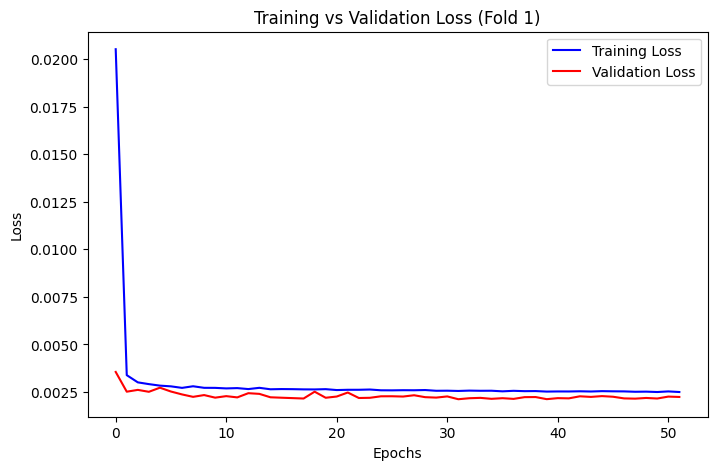

Fold 2/5


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6             │ (None, 18, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_6 (Conv1D)         │ (None, 18, 8)          │             32 │ input_layer_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_6 (Flatten)       │ (None, 144)            │              0 │ conv1d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_12 (Dense)          │ (None, 128)            │         18,560 │ flatten_6[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_13 (Dense)          │ (None, 64)             │          8,256 │ dense_12[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dense_13[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dense_13[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dense_13[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dense_13[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dense_13[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_childcare (Dense)  │ (None, 1)              │             65 │ dense_13[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_taxes (Dense)      │ (None, 1)              │             65 │ dense_13[0][0]         │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 27,303 (106.65 KB)

 Trainable params: 27,303 (106.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0539 - target_childcare_loss: 0.0165 - target_food_loss: 0.0073 - target_healthcare_loss: 0.0051 - target_housing_loss: 0.0102 - target_othernecessities_loss: 0.0052 - target_taxes_loss: 0.0025 - target_transportation_loss: 0.0070 - val_loss: 0.0032 - val_target_childcare_loss: 3.0795e-04 - val_target_food_loss: 3.0545e-04 - val_target_healthcare_loss: 6.6524e-04 - val_target_housing_loss: 5.4323e-04 - val_target_othernecessities_loss: 1.9402e-04 - val_target_taxes_loss: 2.3391e-04 - val_target_transportation_loss: 9.1355e-04
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0033 - target_childcare_loss: 3.5532e-04 - target_food_loss: 3.2278e-04 - target_healthcare_loss: 7.1972e-04 - target_housing_loss: 3.8738e-04 - target_othernecessities_loss: 2.1907e-04 - target_taxes_loss: 1.6828e-04 - target_transportation_loss: 0.0011 - val_loss: 0.0026 - val_target_childcare_loss: 2.7143e-04 - val_target_food_loss: 2.18

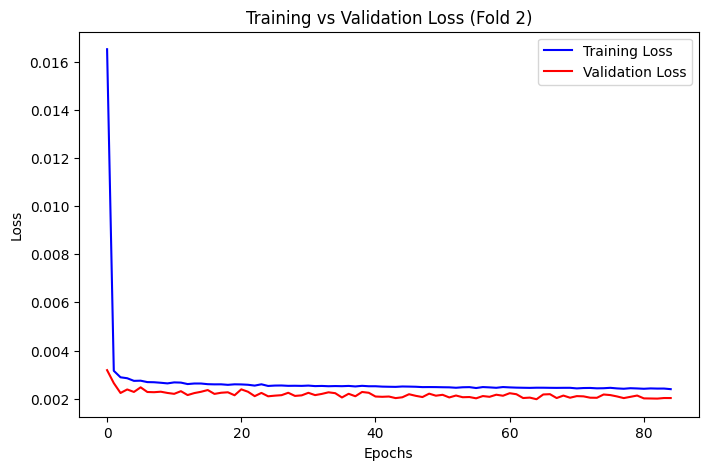

Fold 3/5


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7             │ (None, 18, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_7 (Conv1D)         │ (None, 18, 8)          │             32 │ input_layer_7[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_7 (Flatten)       │ (None, 144)            │              0 │ conv1d_7[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_14 (Dense)          │ (None, 128)            │         18,560 │ flatten_7[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_15 (Dense)          │ (None, 64)             │          8,256 │ dense_14[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dense_15[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dense_15[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dense_15[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dense_15[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dense_15[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_childcare (Dense)  │ (None, 1)              │             65 │ dense_15[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_taxes (Dense)      │ (None, 1)              │             65 │ dense_15[0][0]         │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 27,303 (106.65 KB)

 Trainable params: 27,303 (106.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0406 - target_childcare_loss: 0.0068 - target_food_loss: 0.0025 - target_healthcare_loss: 0.0076 - target_housing_loss: 0.0045 - target_othernecessities_loss: 0.0057 - target_taxes_loss: 0.0027 - target_transportation_loss: 0.0108 - val_loss: 0.0033 - val_target_childcare_loss: 2.6680e-04 - val_target_food_loss: 3.6755e-04 - val_target_healthcare_loss: 6.3115e-04 - val_target_housing_loss: 3.4006e-04 - val_target_othernecessities_loss: 2.0994e-04 - val_target_taxes_loss: 1.8726e-04 - val_target_transportation_loss: 0.0012
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0034 - target_childcare_loss: 3.4553e-04 - target_food_loss: 3.1226e-04 - target_healthcare_loss: 7.3667e-04 - target_housing_loss: 3.7748e-04 - target_othernecessities_loss: 2.4688e-04 - target_taxes_loss: 1.5027e-04 - target_transportation_loss: 0.0012 - val_loss: 0.0023 - val_target_childcare_loss: 2.4995e-04 - val_target_food_loss: 1.9733e-

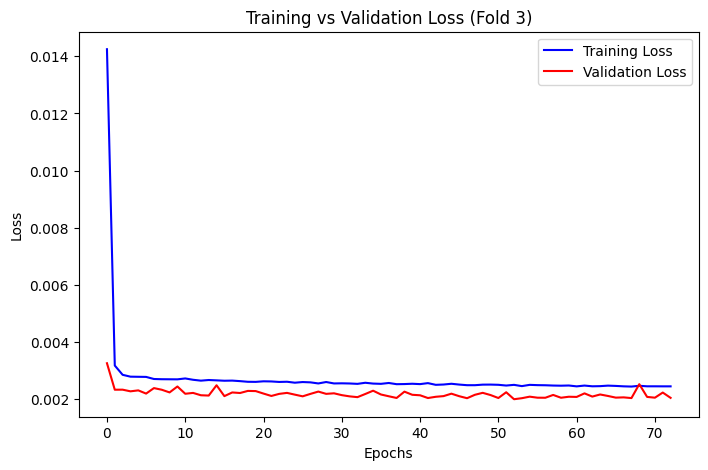

Fold 4/5


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8             │ (None, 18, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_8 (Conv1D)         │ (None, 18, 8)          │             32 │ input_layer_8[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_8 (Flatten)       │ (None, 144)            │              0 │ conv1d_8[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_16 (Dense)          │ (None, 128)            │         18,560 │ flatten_8[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_17 (Dense)          │ (None, 64)             │          8,256 │ dense_16[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dense_17[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dense_17[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dense_17[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dense_17[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dense_17[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_childcare (Dense)  │ (None, 1)              │             65 │ dense_17[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_taxes (Dense)      │ (None, 1)              │             65 │ dense_17[0][0]         │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 27,303 (106.65 KB)

 Trainable params: 27,303 (106.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0361 - target_childcare_loss: 0.0049 - target_food_loss: 0.0024 - target_healthcare_loss: 0.0058 - target_housing_loss: 0.0030 - target_othernecessities_loss: 0.0054 - target_taxes_loss: 0.0034 - target_transportation_loss: 0.0112 - val_loss: 0.0030 - val_target_childcare_loss: 3.7018e-04 - val_target_food_loss: 3.4733e-04 - val_target_healthcare_loss: 5.9406e-04 - val_target_housing_loss: 2.7788e-04 - val_target_othernecessities_loss: 2.3931e-04 - val_target_taxes_loss: 1.9330e-04 - val_target_transportation_loss: 9.7693e-04
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0033 - target_childcare_loss: 3.6701e-04 - target_food_loss: 3.1574e-04 - target_healthcare_loss: 7.4935e-04 - target_housing_loss: 3.3663e-04 - target_othernecessities_loss: 2.5370e-04 - target_taxes_loss: 1.3609e-04 - target_transportation_loss: 0.0011 - val_loss: 0.0024 - val_target_childcare_loss: 2.8963e-04 - val_target_food_loss: 1.65

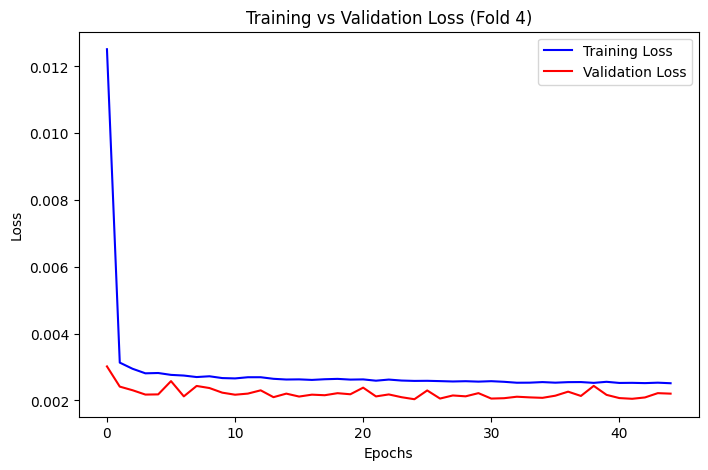

Fold 5/5


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9             │ (None, 18, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_9 (Conv1D)         │ (None, 18, 8)          │             32 │ input_layer_9[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_9 (Flatten)       │ (None, 144)            │              0 │ conv1d_9[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_18 (Dense)          │ (None, 128)            │         18,560 │ flatten_9[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_19 (Dense)          │ (None, 64)             │          8,256 │ dense_18[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dense_19[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dense_19[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dense_19[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dense_19[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dense_19[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_childcare (Dense)  │ (None, 1)              │             65 │ dense_19[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_taxes (Dense)      │ (None, 1)              │             65 │ dense_19[0][0]         │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 27,303 (106.65 KB)

 Trainable params: 27,303 (106.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0532 - target_childcare_loss: 0.0080 - target_food_loss: 0.0088 - target_healthcare_loss: 0.0114 - target_housing_loss: 0.0044 - target_othernecessities_loss: 0.0074 - target_taxes_loss: 0.0024 - target_transportation_loss: 0.0109 - val_loss: 0.0049 - val_target_childcare_loss: 6.9033e-04 - val_target_food_loss: 5.9752e-04 - val_target_healthcare_loss: 0.0010 - val_target_housing_loss: 6.0109e-04 - val_target_othernecessities_loss: 3.7240e-04 - val_target_taxes_loss: 2.1384e-04 - val_target_transportation_loss: 0.0015
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0031 - target_childcare_loss: 3.3625e-04 - target_food_loss: 4.0297e-04 - target_healthcare_loss: 6.1808e-04 - target_housing_loss: 3.4906e-04 - target_othernecessities_loss: 2.3082e-04 - target_taxes_loss: 1.6882e-04 - target_transportation_loss: 9.8985e-04 - val_loss: 0.0042 - val_target_childcare_loss: 4.9491e-04 - val_target_food_loss: 4.4459e-

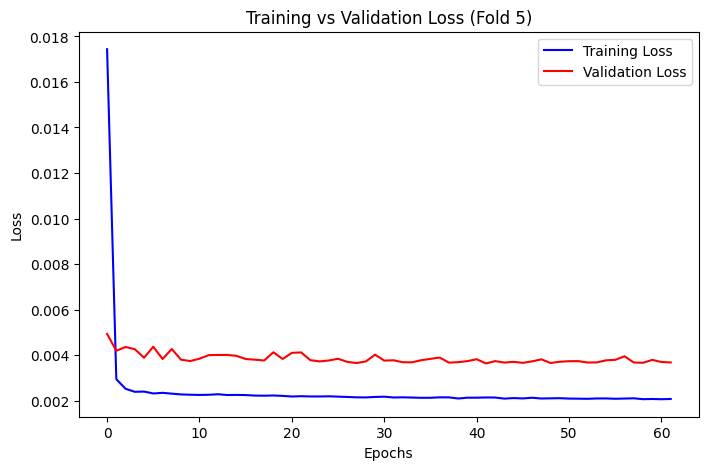

In [17]:
def cross_val_with_evaluation(X_scaled, y_exp_scaled, kf, num_epochs=200):
    fold = 1
    models = []  # Store models for all folds
    all_results = []  # Store results across folds

    for train_index, val_index in kf.split(X_scaled):
        print(f"Fold {fold}/{kf.get_n_splits()}")

        X_train, X_test_val = X_scaled[train_index], X_scaled[val_index]
        y_train, y_test_val = y_exp_scaled[train_index], y_exp_scaled[val_index]

        X_test, X_val, y_test, y_val = train_test_split(
            X_test_val, y_test_val, test_size=0.5, random_state=100
        )  # 50/50 split of remaining 20%

        # Reshaping data for CNN
        X_train = X_train[..., np.newaxis]
        X_val = X_val[..., np.newaxis]
        X_test = X_test[..., np.newaxis]

        model = create_hybrid_model((X_train.shape[1], 1), y_train.shape[1])
        model.compile(optimizer=Adam(learning_rate=0.001), loss="mean_squared_error")
        early_stopping = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

        model.summary()

        # Training
        history = model.fit(
            X_train,
            [y_train[:, i] for i in range(y_train.shape[1])],
            validation_data=(X_val, [y_val[:, i] for i in range(y_val.shape[1])]),
            epochs=num_epochs,
            batch_size=64,
            verbose=1,
            callbacks=[early_stopping],
        )

        # Predictions
        y_train_pred = np.column_stack(model.predict(X_train))
        y_val_pred = np.column_stack(model.predict(X_val))
        y_test_pred = np.column_stack(model.predict(X_test))

        # Inverse scaling
        y_train_pred_original = scaler_y.inverse_transform(y_train_pred)
        y_train_original = scaler_y.inverse_transform(y_train)
        y_val_pred_original = scaler_y.inverse_transform(y_val_pred)
        y_val_original = scaler_y.inverse_transform(y_val)
        y_test_pred_original = scaler_y.inverse_transform(y_test_pred)
        y_test_original = scaler_y.inverse_transform(y_test)

        # Enforce childcare expense rule
        y_train_pred_original[:, childcare_exp_col] = np.where(
            X_train[:, num_children_col, 0] == 0, 0, y_train_pred_original[:, childcare_exp_col]
        )

        y_val_pred_original[:, childcare_exp_col] = np.where(
            X_val[:, num_children_col, 0] == 0, 0, y_val_pred_original[:, childcare_exp_col]
        )

        y_test_pred_original[:, childcare_exp_col] = np.where(
            X_test[:, num_children_col, 0] == 0, 0, y_test_pred_original[:, childcare_exp_col]
        )

        # Store fold-wise results
        fold_results = {}
        for i, target in enumerate(target_col_list):
            fold_results[target] = {
                "Train": regr_report(y_train_original[:, i], y_train_pred_original[:, i]),
                "Validation": regr_report(y_val_original[:, i], y_val_pred_original[:, i]),
                "Test": regr_report(y_test_original[:, i], y_test_pred_original[:, i]),
            }

        all_results.append(fold_results)

         # Metrics for each target
        for i, target in enumerate(target_col_list):
            print(f'Model Results for {target.capitalize()}:')
            print('Train Data:', regr_report(y_train_original[:, i], y_train_pred_original[:, i]))
            print('Validation Data:', regr_report(y_val_original[:, i], y_val_pred_original[:, i]))
            print('Test Data:', regr_report(y_test_original[:, i], y_test_pred_original[:, i])) #Print metrics for test set
            print()

        # Plot training & validation loss
        plt.figure(figsize=(8, 5))
        plt.plot(history.history["loss"], label="Training Loss", color="blue")
        plt.plot(history.history["val_loss"], label="Validation Loss", color="red")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title(f"Training vs Validation Loss (Fold {fold})")
        plt.legend()
        plt.show()

        # Store trained model
        models.append(model)

        fold += 1

    return models, all_results  # Return all trained models and evaluation results

# Running Cross-Validation
models, results = cross_val_with_evaluation(additional_features, y_exp_scaled, kf)

# Save the last trained model's weights
models[-1].save_weights("final_model_expenses.weights.h5")

**Model testing**

In [18]:
# Cross-Validation with Evaluation
def cross_val_with_evaluation(X_scaled, y_exp_scaled, kf, num_epochs=200):
    fold = 1
    test_data_storage = []  # List to store test data for all folds

    for train_index, val_index in kf.split(X_scaled):
        print(f"Fold {fold}/{kf.get_n_splits()}")
        X_train, X_test_val = X_scaled[train_index], X_scaled[val_index]
        y_train, y_test_val = y_exp_scaled[train_index], y_exp_scaled[val_index]

        # Splitting test and validation sets
        X_test, X_val, y_test, y_val = train_test_split(X_test_val, y_test_val, test_size=0.5, random_state=100)

        # Reshaping data for CNN
        X_train = X_train[..., np.newaxis]
        X_val = X_val[..., np.newaxis]
        X_test = X_test[..., np.newaxis]

        # Create and compile model
        model = create_hybrid_model((X_train.shape[1], 1), y_train.shape[1])
        model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
        early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

        model.summary()

        # Training
        model.fit(X_train, [y_train[:, i] for i in range(y_train.shape[1])],
                  validation_data=(X_val, [y_val[:, i] for i in range(y_val.shape[1])]),
                  epochs=num_epochs, batch_size=64, verbose=1, callbacks=[early_stopping])

        # Predictions
        y_test_pred = np.column_stack(model.predict(X_test))

        # Inverse scaling
        y_test_pred_original = scaler_y.inverse_transform(y_test_pred)
        y_test_original = scaler_y.inverse_transform(y_test)

        # Enforce rule for childcare expense
        y_test_pred_original[:, childcare_exp_col] = np.where(
            X_test[:, num_children_col, 0] == 0, 0, y_test_pred_original[:, childcare_exp_col])

        # Store test data for this fold
        test_data = {
            "X_test": X_test,
            "y_test_original": y_test_original,
            "y_test_pred_original": y_test_pred_original
        }
        test_data_storage.append(test_data)

        # Metrics for each target
        for i, target in enumerate(target_col_list):
            print(f'Model Results for {target.capitalize()} (Fold {fold}):')
            print('Test Data:', regr_report(y_test_original[:, i], y_test_pred_original[:, i]))

        fold += 1

    # Save the test data to a file
    with open('test_data.pkl', 'wb') as f:
        pickle.dump(test_data_storage, f)

    print("Test data has been saved to 'test_data.pkl'")
    return model

# Example usage
model_combine = cross_val_with_evaluation(additional_features, y_exp_scaled, kf)
model_combine.save_weights("test_model_expenses.weights.h5")


Fold 1/5


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10            │ (None, 18, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_10 (Conv1D)        │ (None, 18, 8)          │             32 │ input_layer_10[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_10 (Flatten)      │ (None, 144)            │              0 │ conv1d_10[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_20 (Dense)          │ (None, 128)            │         18,560 │ flatten_10[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_21 (Dense)          │ (None, 64)             │          8,256 │ dense_20[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dense_21[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dense_21[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dense_21[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dense_21[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dense_21[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_childcare (Dense)  │ (None, 1)              │             65 │ dense_21[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_taxes (Dense)      │ (None, 1)              │             65 │ dense_21[0][0]         │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 27,303 (106.65 KB)

 Trainable params: 27,303 (106.65 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14            │ (None, 18, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_14 (Conv1D)        │ (None, 18, 8)          │             32 │ input_layer_14[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_14 (Flatten)      │ (None, 144)            │              0 │ conv1d_14[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_28 (Dense)          │ (None, 128)            │         18,560 │ flatten_14[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_29 (Dense)          │ (None, 64)             │          8,256 │ dense_28[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dense_29[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dense_29[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dense_29[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dense_29[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dense_29[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_childcare (Dense)  │ (None, 1)              │             65 │ dense_29[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_taxes (Dense)      │ (None, 1)              │             65 │ dense_29[0][0]         │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 27,303 (106.65 KB)

 Trainable params: 27,303 (106.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0467 - target_childcare_loss: 0.0055 - target_food_loss: 0.0072 - target_healthcare_loss: 0.0078 - target_housing_loss: 0.0036 - target_othernecessities_loss: 0.0092 - target_taxes_loss: 0.0020 - target_transportation_loss: 0.0114 - val_loss: 0.0047 - val_target_childcare_loss: 5.1625e-04 - val_target_food_loss: 4.6560e-04 - val_target_healthcare_loss: 0.0010 - val_target_housing_loss: 4.7847e-04 - val_target_othernecessities_loss: 3.9780e-04 - val_target_taxes_loss: 2.1236e-04 - val_target_transportation_loss: 0.0016
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0028 - target_childcare_loss: 3.1197e-04 - target_food_loss: 2.8578e-04 - target_healthcare_loss: 6.0713e-04 - target_housing_loss: 2.9650e-04 - target_othernecessities_loss: 2.1726e-04 - target_taxes_loss: 1.7909e-04 - target_transportation_loss: 9.5216e-04 - val_loss: 0.0043 - val_target_childcare_loss: 4.6640e-04 - val_target_food_loss: 4.0672e-

In [19]:
import pandas as pd
import numpy as np
import joblib
from tqdm import tqdm
# Load the scalers and test data
scaler_X = joblib.load('scaler_X.pkl')
scaler_y = joblib.load('scaler_y.pkl')
TEST_DATA = joblib.load('test_data.pkl')  # Loading the actual test data
if isinstance(TEST_DATA, list):
    TEST_DATA = pd.DataFrame(TEST_DATA)


test_data = TEST_DATA.head(3)
test_data

,X_test,y_test_original,y_test_pred_original
0,"[[[0.29058561897702007], [0.3800610087729669],...","[[1443.0, 880.0, 1724.0, 1169.0, 782.0, 1509.0...","[[1321.5116, 883.5736, 1699.8162, 1216.8003, 7..."
1,"[[[0.1077835433654559], [0.3945848802289011], ...","[[865.0, 440.99999999999994, 1417.0, 728.0, 43...","[[906.55115, 435.2955, 1400.4166, 722.96796, 4..."
2,"[[[0.2786261428218434], [0.29529191988460357],...","[[1130.0, 1218.0, 1724.0, 1802.0, 790.0, 923.0...","[[1161.1382, 1217.0427, 1711.3541, 1782.208, 8..."


In [20]:
import pandas as pd
import numpy as np
import joblib
from tqdm import tqdm

# Load the scalers and test data
scaler_X = joblib.load('scaler_X.pkl')
scaler_y = joblib.load('scaler_y.pkl')
TEST_DATA = joblib.load('test_data.pkl')  # Loading the actual test data

# Check if TEST_DATA is a list and convert it to DataFrame
if isinstance(TEST_DATA, list):
    TEST_DATA = pd.DataFrame(TEST_DATA)

# Extract the original values and predicted values from the test data
y_test_original = TEST_DATA['y_test_original'].values
y_test_pred_original = TEST_DATA['y_test_pred_original'].values

# Define the target columns
target_col_list = ['housing', 'food', 'transportation', 'healthcare', 'othernecessities', 'childcare', 'taxes']

# Limit to 2 rows for output
for i, (true_val, pred_val) in enumerate(zip(y_test_original[:3], y_test_pred_original[:3])):  # Only process the first 2 rows
    print(f"\nRow {i+1}:")
    # Ensure j does not exceed the length of target_col_list or true_val/pred_val
    for j in range(min(len(target_col_list), len(true_val), len(pred_val))):
        # Accessing the first element of true and pred (assuming they are lists or arrays)
        print(f"{target_col_list[j]} - True: {true_val[j][0]:.2f}, Pred: {pred_val[j][0]:.2f}")





Row 1:
housing - True: 1443.00, Pred: 1321.51
food - True: 1215.00, Pred: 1213.48
transportation - True: 1060.00, Pred: 994.63
healthcare - True: 1164.00, Pred: 1203.92
othernecessities - True: 1036.00, Pred: 956.74
childcare - True: 1065.00, Pred: 1069.36
taxes - True: 834.00, Pred: 807.08

Row 2:
housing - True: 865.00, Pred: 906.55
food - True: 698.00, Pred: 728.46
transportation - True: 2042.00, Pred: 1988.36
healthcare - True: 903.00, Pred: 900.06
othernecessities - True: 1040.00, Pred: 1075.65
childcare - True: 1601.00, Pred: 1668.46
taxes - True: 893.00, Pred: 846.99

Row 3:
housing - True: 1130.00, Pred: 1161.14
food - True: 1101.00, Pred: 1172.00
transportation - True: 946.00, Pred: 827.37
healthcare - True: 1191.00, Pred: 1088.04
othernecessities - True: 933.00, Pred: 929.38
childcare - True: 2844.00, Pred: 2792.63
taxes - True: 1094.00, Pred: 1266.78


Fold 1/5


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15            │ (None, 18, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_15 (Conv1D)        │ (None, 18, 8)          │             32 │ input_layer_15[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_15 (Flatten)      │ (None, 144)            │              0 │ conv1d_15[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_30 (Dense)          │ (None, 128)            │         18,560 │ flatten_15[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_31 (Dense)          │ (None, 64)             │          8,256 │ dense_30[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dense_31[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dense_31[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dense_31[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dense_31[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dense_31[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_childcare (Dense)  │ (None, 1)              │             65 │ dense_31[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_taxes (Dense)      │ (None, 1)              │             65 │ dense_31[0][0]         │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 27,303 (106.65 KB)

 Trainable params: 27,303 (106.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0333 - target_childcare_loss: 0.0030 - target_food_loss: 0.0096 - target_healthcare_loss: 0.0076 - target_housing_loss: 0.0037 - target_othernecessities_loss: 0.0034 - target_taxes_loss: 0.0022 - target_transportation_loss: 0.0039 - val_loss: 0.0034 - val_target_childcare_loss: 3.1305e-04 - val_target_food_loss: 4.5300e-04 - val_target_healthcare_loss: 5.9107e-04 - val_target_housing_loss: 3.1425e-04 - val_target_othernecessities_loss: 2.0064e-04 - val_target_taxes_loss: 1.6830e-04 - val_target_transportation_loss: 0.0014
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0033 - target_childcare_loss: 3.8060e-04 - target_food_loss: 3.9266e-04 - target_healthcare_loss: 6.8402e-04 - target_housing_loss: 3.7352e-04 - target_othernecessities_loss: 2.2726e-04 - target_taxes_loss: 1.5812e-04 - target_transportation_loss: 0.0011 - val_loss: 0.0027 - val_target_childcare_loss: 2.9280e-04 - val_target_food_loss: 2.9768e-

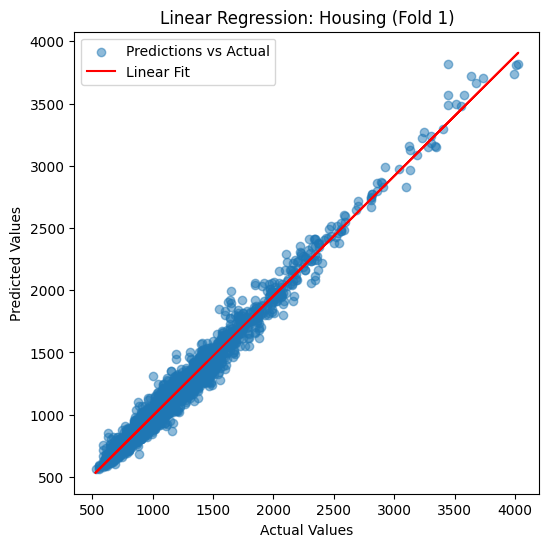

Model Results for Food (Fold 1):
Test Data: MAE: 24.9837, R-Squared: 0.9898, RMSE: 34.8949, MSE: 1217.6546 ,smape: 2.9442797066835293, mape: 2.9252
R^2 Score for Food: 0.9906


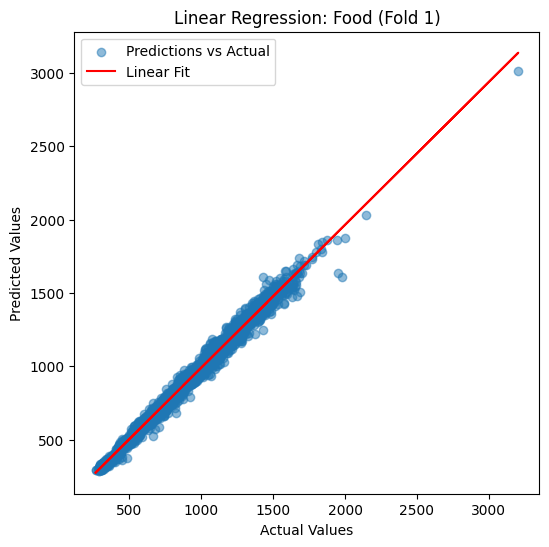

Model Results for Transportation (Fold 1):
Test Data: MAE: 51.0188, R-Squared: 0.9152, RMSE: 70.3903, MSE: 4954.7925 ,smape: 3.296153511757312, mape: 3.3447
R^2 Score for Transportation: 0.9159


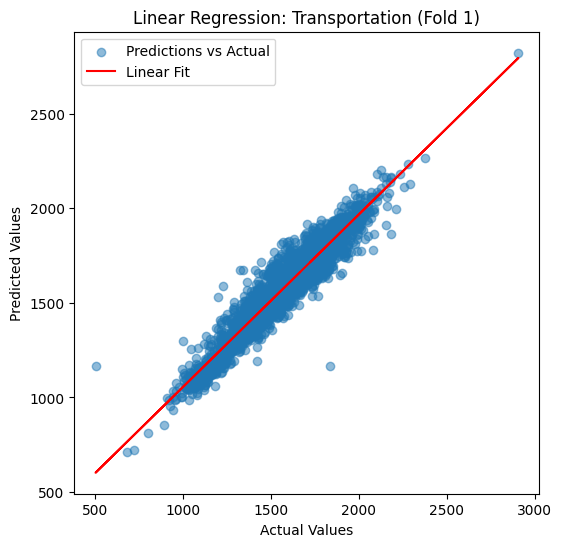

Model Results for Healthcare (Fold 1):
Test Data: MAE: 53.249, R-Squared: 0.9805, RMSE: 73.2693, MSE: 5368.3852 ,smape: 4.273872913378217, mape: 4.2796
R^2 Score for Healthcare: 0.9805


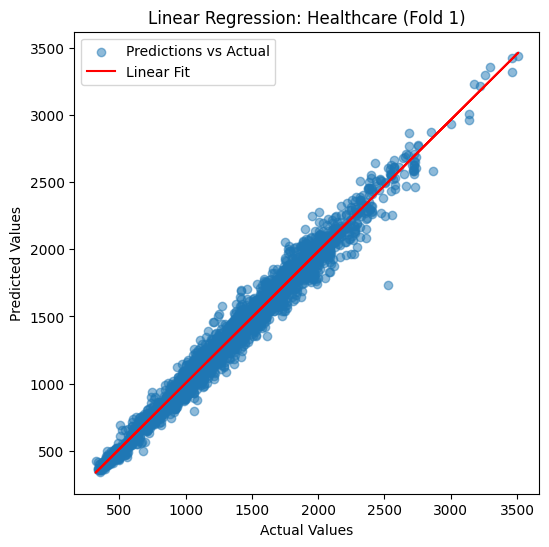

Model Results for Othernecessities (Fold 1):
Test Data: MAE: 20.151, R-Squared: 0.9858, RMSE: 27.2774, MSE: 744.0582 ,smape: 2.9837291894336917, mape: 2.9489
R^2 Score for Othernecessities: 0.9881


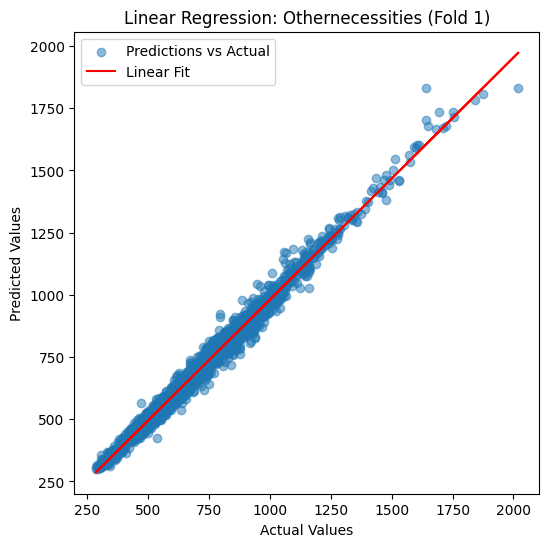

Model Results for Childcare (Fold 1):
Test Data: MAE: 51.5423, R-Squared: 0.9873, RMSE: 77.1637, MSE: 5954.2425 ,smape: 4.652796858258559, mape: 4.7386
R^2 Score for Childcare: 0.9874


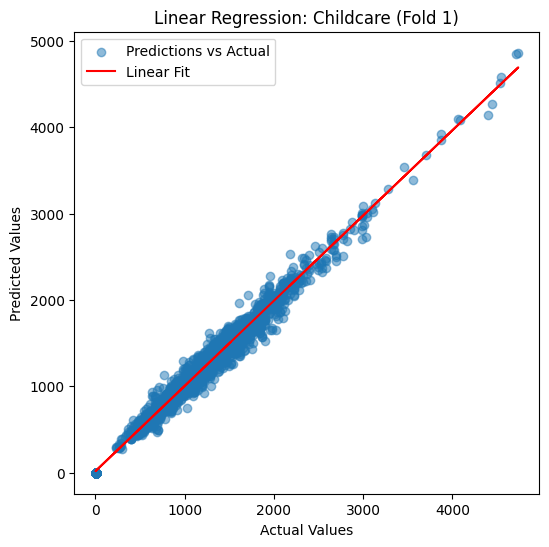

Model Results for Taxes (Fold 1):
Test Data: MAE: 16.376, R-Squared: 0.9971, RMSE: 24.39, MSE: 594.8705 ,smape: 1.703581130994927, mape: 1.7172
R^2 Score for Taxes: 0.9972


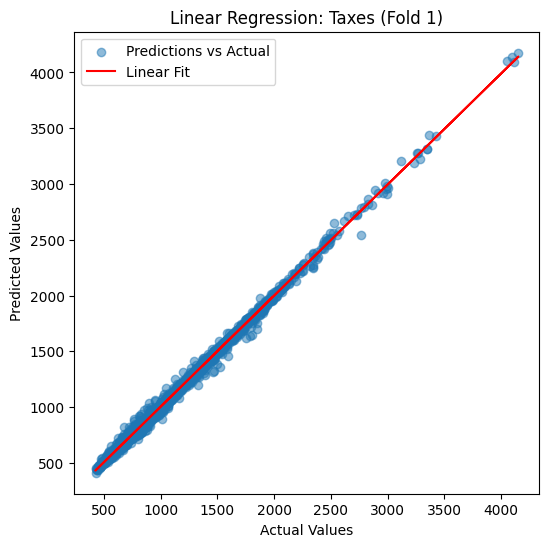

Fold 2/5


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16            │ (None, 18, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_16 (Conv1D)        │ (None, 18, 8)          │             32 │ input_layer_16[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_16 (Flatten)      │ (None, 144)            │              0 │ conv1d_16[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_32 (Dense)          │ (None, 128)            │         18,560 │ flatten_16[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_33 (Dense)          │ (None, 64)             │          8,256 │ dense_32[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dense_33[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dense_33[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dense_33[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dense_33[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dense_33[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_childcare (Dense)  │ (None, 1)              │             65 │ dense_33[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_taxes (Dense)      │ (None, 1)              │             65 │ dense_33[0][0]         │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 27,303 (106.65 KB)

 Trainable params: 27,303 (106.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0530 - target_childcare_loss: 0.0051 - target_food_loss: 0.0085 - target_healthcare_loss: 0.0136 - target_housing_loss: 0.0048 - target_othernecessities_loss: 0.0057 - target_taxes_loss: 0.0033 - target_transportation_loss: 0.0120 - val_loss: 0.0030 - val_target_childcare_loss: 3.2208e-04 - val_target_food_loss: 3.3351e-04 - val_target_healthcare_loss: 6.2039e-04 - val_target_housing_loss: 3.2142e-04 - val_target_othernecessities_loss: 2.2870e-04 - val_target_taxes_loss: 8.1976e-05 - val_target_transportation_loss: 0.0011
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0033 - target_childcare_loss: 3.7113e-04 - target_food_loss: 3.6103e-04 - target_healthcare_loss: 7.2614e-04 - target_housing_loss: 3.6529e-04 - target_othernecessities_loss: 2.4081e-04 - target_taxes_loss: 6.7918e-05 - target_transportation_loss: 0.0012 - val_loss: 0.0027 - val_target_childcare_loss: 3.0916e-04 - val_target_food_loss: 2.6322e-

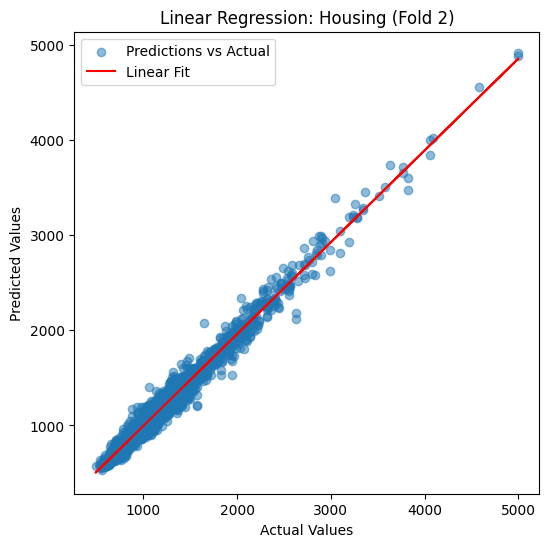

Model Results for Food (Fold 2):
Test Data: MAE: 26.0236, R-Squared: 0.9902, RMSE: 34.1498, MSE: 1166.2079 ,smape: 3.211035758013361, mape: 3.2688
R^2 Score for Food: 0.9914


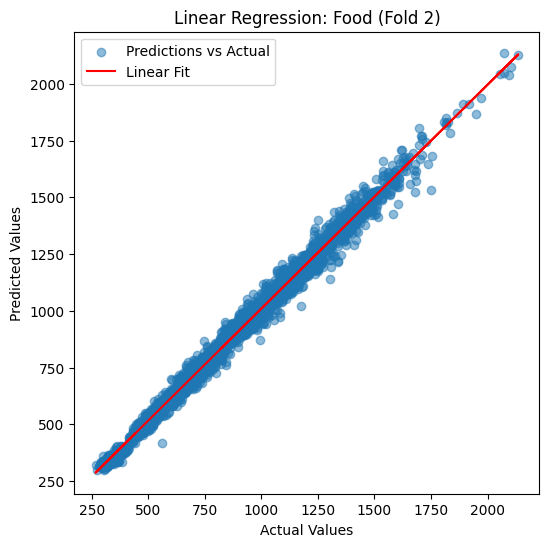

Model Results for Transportation (Fold 2):
Test Data: MAE: 52.2644, R-Squared: 0.9152, RMSE: 68.9995, MSE: 4760.9355 ,smape: 3.3847514709689284, mape: 3.3961
R^2 Score for Transportation: 0.9170


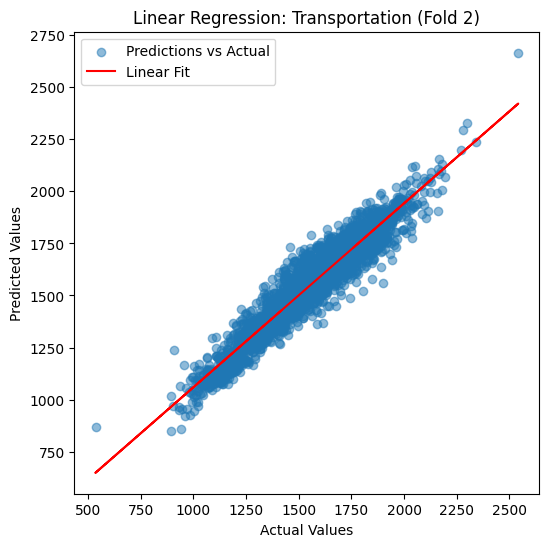

Model Results for Healthcare (Fold 2):
Test Data: MAE: 53.4053, R-Squared: 0.979, RMSE: 75.481, MSE: 5697.3757 ,smape: 4.343076277681552, mape: 4.4082
R^2 Score for Healthcare: 0.9792


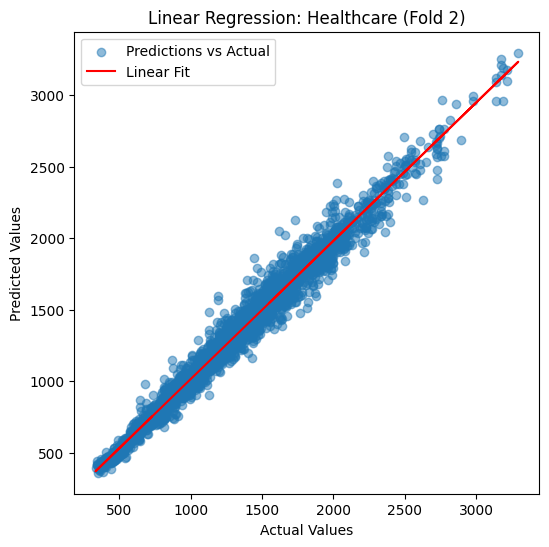

Model Results for Othernecessities (Fold 2):
Test Data: MAE: 18.4842, R-Squared: 0.9889, RMSE: 25.2841, MSE: 639.2837 ,smape: 2.7346217302853497, mape: 2.7509
R^2 Score for Othernecessities: 0.9891


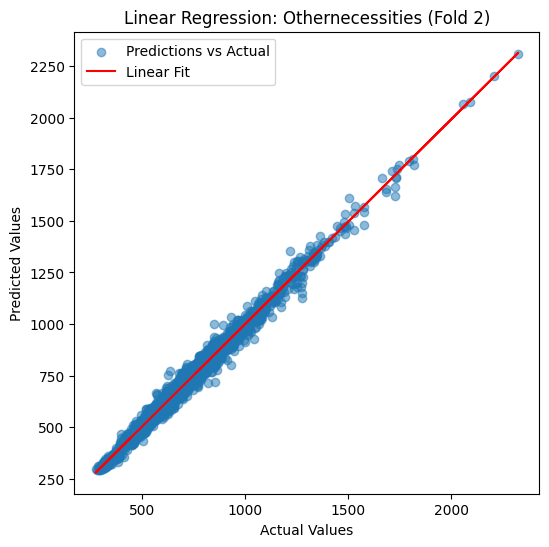

Model Results for Childcare (Fold 2):
Test Data: MAE: 53.6468, R-Squared: 0.9851, RMSE: 84.354, MSE: 7115.6044 ,smape: 4.71978738642879, mape: 4.7122
R^2 Score for Childcare: 0.9856


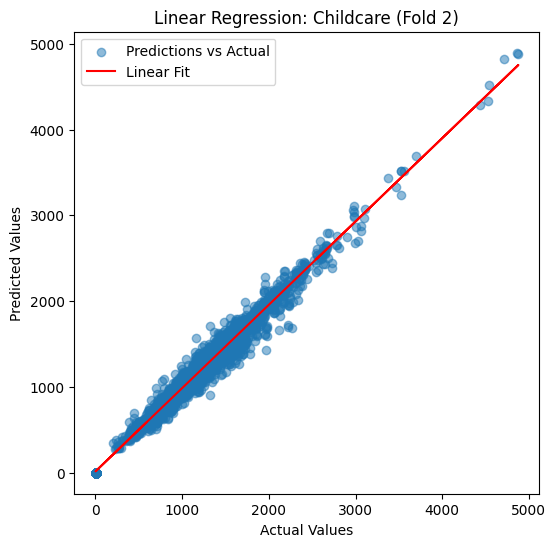

Model Results for Taxes (Fold 2):
Test Data: MAE: 17.9485, R-Squared: 0.9967, RMSE: 26.8871, MSE: 722.9151 ,smape: 1.9894111158090553, mape: 1.9917
R^2 Score for Taxes: 0.9968


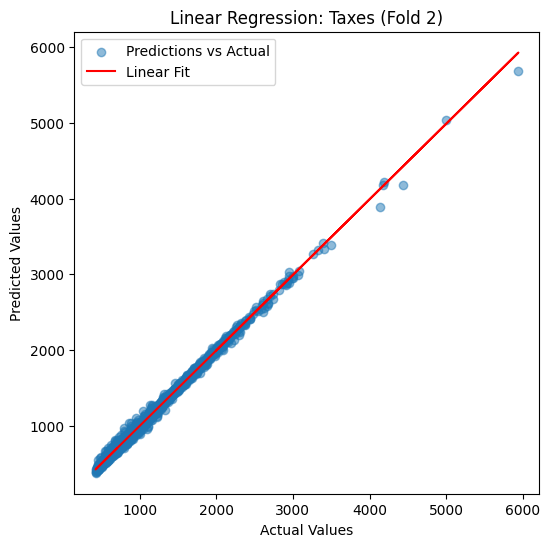

Fold 3/5


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17            │ (None, 18, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_17 (Conv1D)        │ (None, 18, 8)          │             32 │ input_layer_17[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_17 (Flatten)      │ (None, 144)            │              0 │ conv1d_17[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_34 (Dense)          │ (None, 128)            │         18,560 │ flatten_17[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_35 (Dense)          │ (None, 64)             │          8,256 │ dense_34[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dense_35[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dense_35[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dense_35[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dense_35[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dense_35[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_childcare (Dense)  │ (None, 1)              │             65 │ dense_35[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_taxes (Dense)      │ (None, 1)              │             65 │ dense_35[0][0]         │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 27,303 (106.65 KB)

 Trainable params: 27,303 (106.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0545 - target_childcare_loss: 0.0095 - target_food_loss: 0.0069 - target_healthcare_loss: 0.0095 - target_housing_loss: 0.0052 - target_othernecessities_loss: 0.0036 - target_taxes_loss: 0.0026 - target_transportation_loss: 0.0173 - val_loss: 0.0031 - val_target_childcare_loss: 3.2311e-04 - val_target_food_loss: 3.4344e-04 - val_target_healthcare_loss: 6.3450e-04 - val_target_housing_loss: 3.9771e-04 - val_target_othernecessities_loss: 2.2951e-04 - val_target_taxes_loss: 1.9271e-04 - val_target_transportation_loss: 9.5006e-04
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0033 - target_childcare_loss: 3.6526e-04 - target_food_loss: 3.2179e-04 - target_healthcare_loss: 7.2069e-04 - target_housing_loss: 3.6528e-04 - target_othernecessities_loss: 2.5342e-04 - target_taxes_loss: 1.6328e-04 - target_transportation_loss: 0.0011 - val_loss: 0.0026 - val_target_childcare_loss: 3.3898e-04 - val_target_food_loss: 2.0

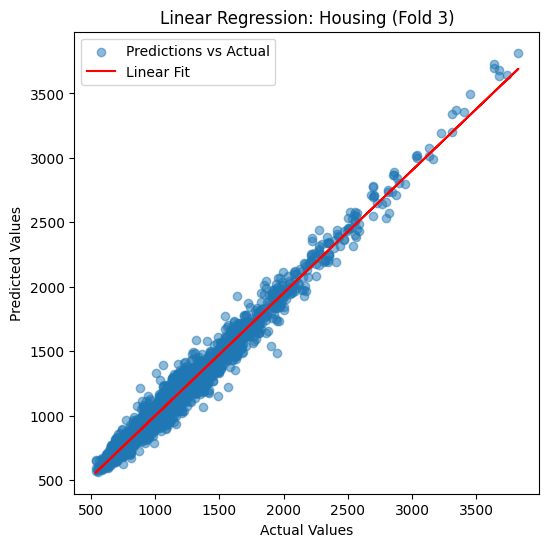

Model Results for Food (Fold 3):
Test Data: MAE: 23.7434, R-Squared: 0.9908, RMSE: 32.5488, MSE: 1059.4243 ,smape: 2.8516674991118456, mape: 2.8349
R^2 Score for Food: 0.9909


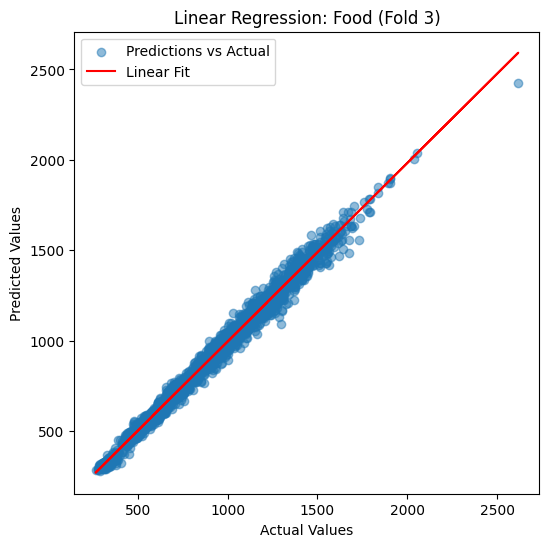

Model Results for Transportation (Fold 3):
Test Data: MAE: 50.9608, R-Squared: 0.9184, RMSE: 66.8829, MSE: 4473.323 ,smape: 3.3246930831928716, mape: 3.3358
R^2 Score for Transportation: 0.9193


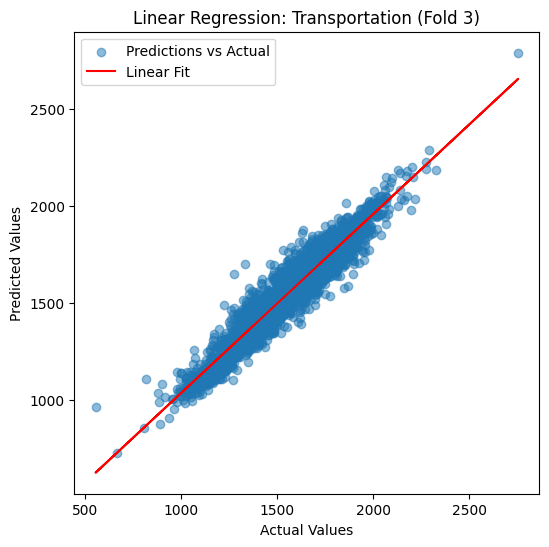

Model Results for Healthcare (Fold 3):
Test Data: MAE: 52.6448, R-Squared: 0.9794, RMSE: 73.534, MSE: 5407.2487 ,smape: 4.234250408360396, mape: 4.2606
R^2 Score for Healthcare: 0.9794


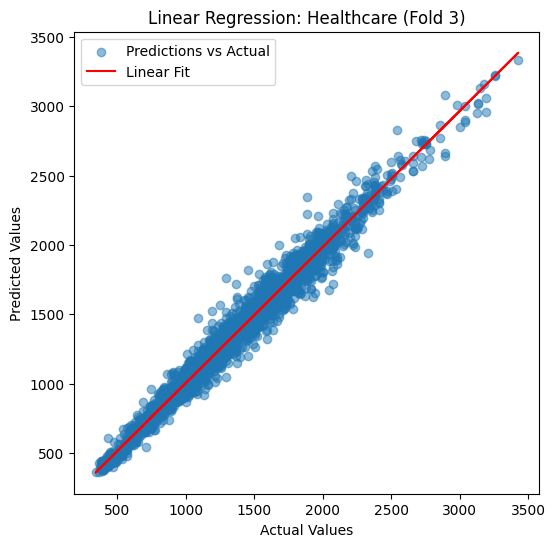

Model Results for Othernecessities (Fold 3):
Test Data: MAE: 18.2801, R-Squared: 0.9882, RMSE: 24.7469, MSE: 612.4112 ,smape: 2.7579605973538452, mape: 2.7496
R^2 Score for Othernecessities: 0.9884


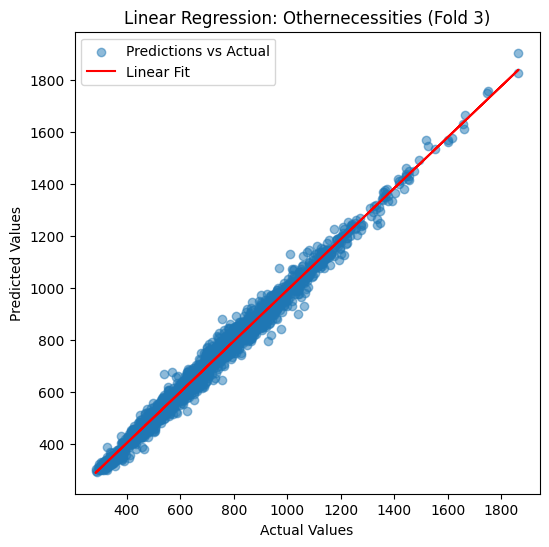

Model Results for Childcare (Fold 3):
Test Data: MAE: 54.0564, R-Squared: 0.9856, RMSE: 81.2405, MSE: 6600.0244 ,smape: 4.944589143717497, mape: 5.1022
R^2 Score for Childcare: 0.9864


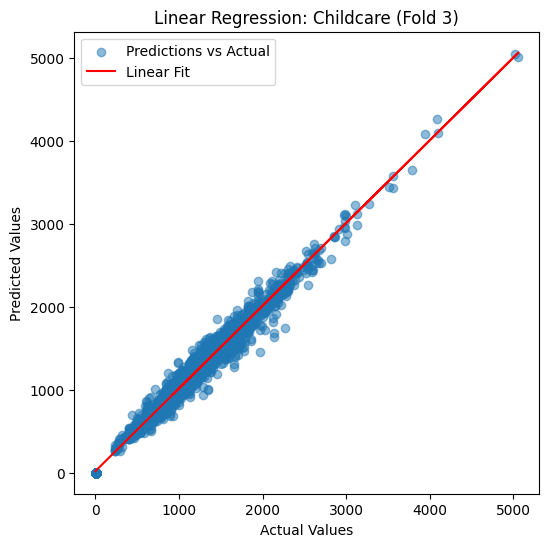

Model Results for Taxes (Fold 3):
Test Data: MAE: 17.1778, R-Squared: 0.997, RMSE: 24.892, MSE: 619.6127 ,smape: 1.8653652747744158, mape: 1.8926
R^2 Score for Taxes: 0.9974


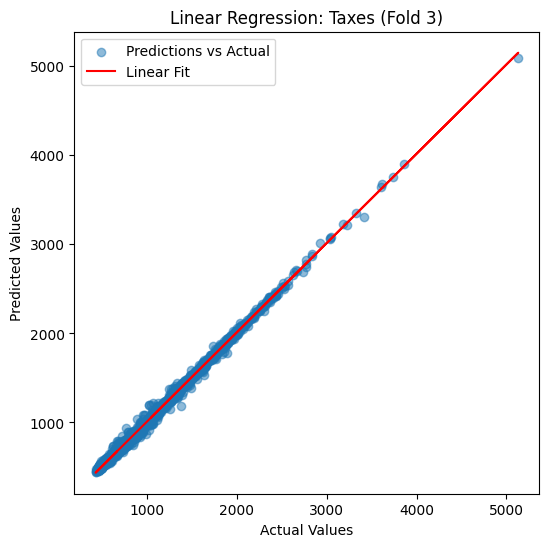

Fold 4/5


Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_18            │ (None, 18, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_18 (Conv1D)        │ (None, 18, 8)          │             32 │ input_layer_18[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_18 (Flatten)      │ (None, 144)            │              0 │ conv1d_18[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_36 (Dense)          │ (None, 128)            │         18,560 │ flatten_18[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_37 (Dense)          │ (None, 64)             │          8,256 │ dense_36[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dense_37[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dense_37[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dense_37[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dense_37[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dense_37[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_childcare (Dense)  │ (None, 1)              │             65 │ dense_37[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_taxes (Dense)      │ (None, 1)              │             65 │ dense_37[0][0]         │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 27,303 (106.65 KB)

 Trainable params: 27,303 (106.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0550 - target_childcare_loss: 0.0122 - target_food_loss: 0.0075 - target_healthcare_loss: 0.0101 - target_housing_loss: 0.0032 - target_othernecessities_loss: 0.0033 - target_taxes_loss: 0.0028 - target_transportation_loss: 0.0159 - val_loss: 0.0029 - val_target_childcare_loss: 2.6591e-04 - val_target_food_loss: 2.7150e-04 - val_target_healthcare_loss: 7.3253e-04 - val_target_housing_loss: 3.3467e-04 - val_target_othernecessities_loss: 1.7686e-04 - val_target_taxes_loss: 1.0727e-04 - val_target_transportation_loss: 9.6321e-04
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0032 - target_childcare_loss: 3.5781e-04 - target_food_loss: 3.1037e-04 - target_healthcare_loss: 7.0573e-04 - target_housing_loss: 3.8722e-04 - target_othernecessities_loss: 2.2278e-04 - target_taxes_loss: 1.1231e-04 - target_transportation_loss: 0.0011 - val_loss: 0.0023 - val_target_childcare_loss: 2.6396e-04 - val_target_food_loss: 1.74

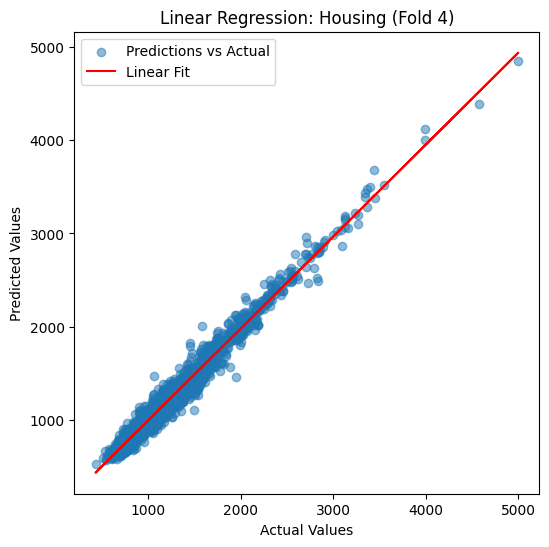

Model Results for Food (Fold 4):
Test Data: MAE: 25.1738, R-Squared: 0.99, RMSE: 34.437, MSE: 1185.9056 ,smape: 3.025312300914298, mape: 3.049
R^2 Score for Food: 0.9903


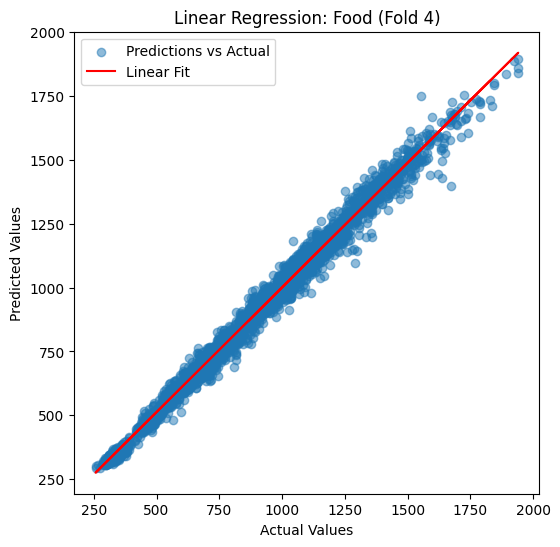

Model Results for Transportation (Fold 4):
Test Data: MAE: 51.4815, R-Squared: 0.919, RMSE: 67.8176, MSE: 4599.2214 ,smape: 3.3569049137614693, mape: 3.3569
R^2 Score for Transportation: 0.9198


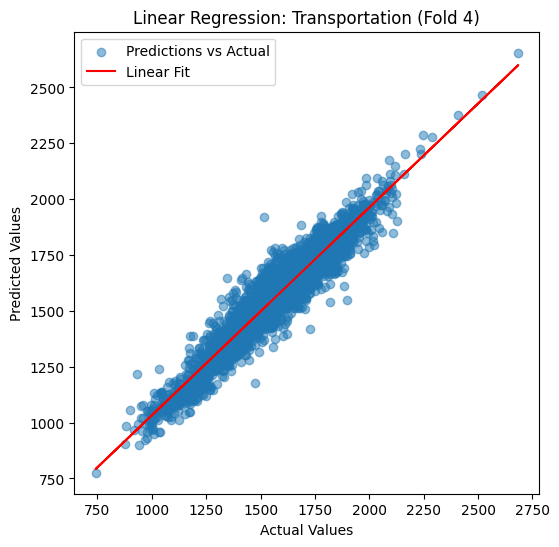

Model Results for Healthcare (Fold 4):
Test Data: MAE: 51.8651, R-Squared: 0.9798, RMSE: 72.9095, MSE: 5315.8003 ,smape: 4.19216184163818, mape: 4.2301
R^2 Score for Healthcare: 0.9799


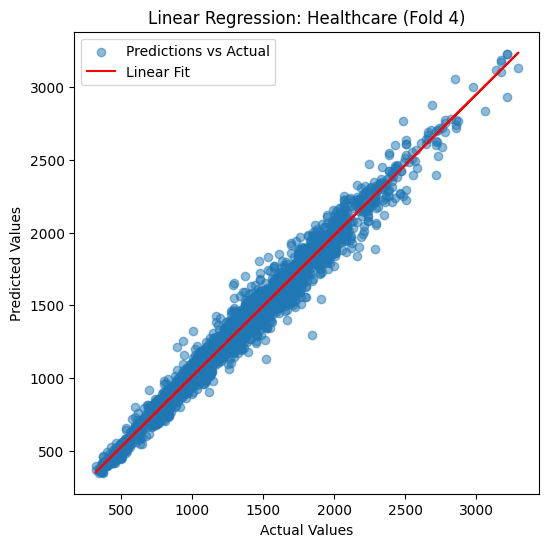

Model Results for Othernecessities (Fold 4):
Test Data: MAE: 19.0985, R-Squared: 0.9878, RMSE: 25.7829, MSE: 664.758 ,smape: 2.873887837983245, mape: 2.8582
R^2 Score for Othernecessities: 0.9881


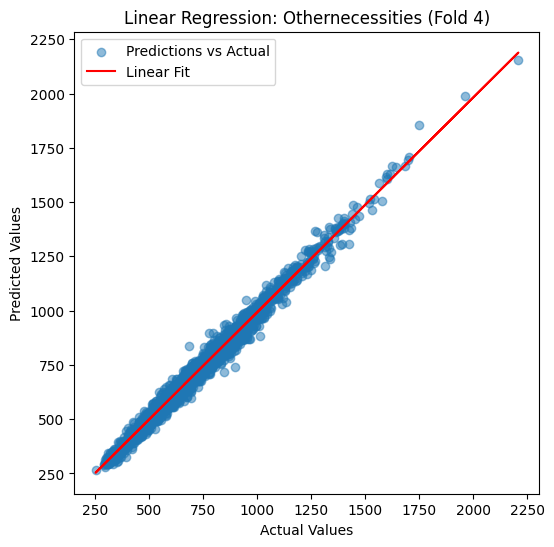

Model Results for Childcare (Fold 4):
Test Data: MAE: 52.2998, R-Squared: 0.9863, RMSE: 80.3805, MSE: 6461.0296 ,smape: 4.639937118322941, mape: 4.6962
R^2 Score for Childcare: 0.9866


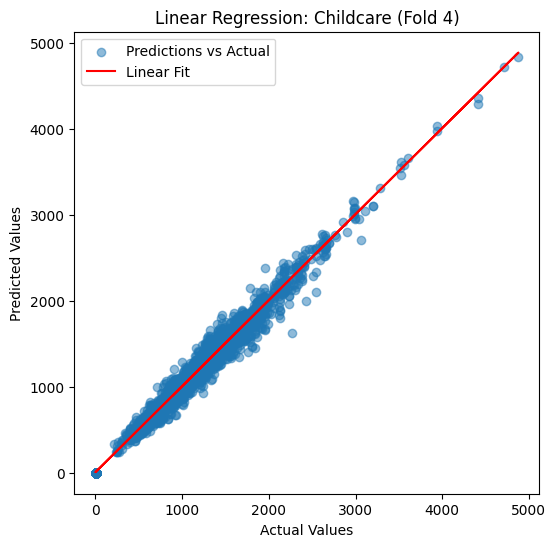

Model Results for Taxes (Fold 4):
Test Data: MAE: 27.2383, R-Squared: 0.9936, RMSE: 37.1044, MSE: 1376.7335 ,smape: 3.1575715831730635, mape: 3.085
R^2 Score for Taxes: 0.9957


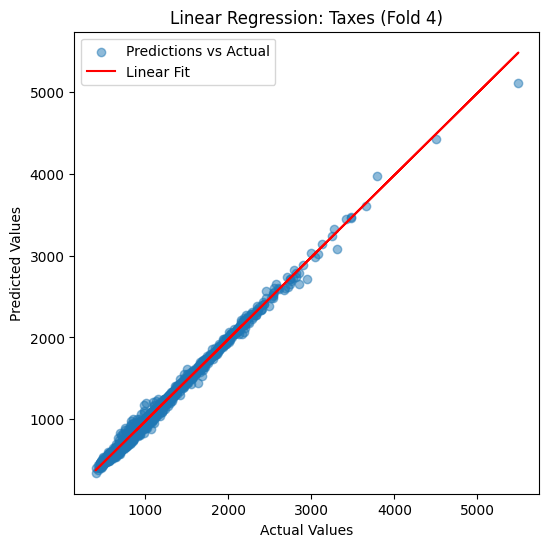

Fold 5/5


Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19            │ (None, 18, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_19 (Conv1D)        │ (None, 18, 8)          │             32 │ input_layer_19[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_19 (Flatten)      │ (None, 144)            │              0 │ conv1d_19[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_38 (Dense)          │ (None, 128)            │         18,560 │ flatten_19[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_39 (Dense)          │ (None, 64)             │          8,256 │ dense_38[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dense_39[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dense_39[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dense_39[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dense_39[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dense_39[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_childcare (Dense)  │ (None, 1)              │             65 │ dense_39[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_taxes (Dense)      │ (None, 1)              │             65 │ dense_39[0][0]         │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 27,303 (106.65 KB)

 Trainable params: 27,303 (106.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0404 - target_childcare_loss: 0.0040 - target_food_loss: 0.0076 - target_healthcare_loss: 0.0059 - target_housing_loss: 0.0020 - target_othernecessities_loss: 0.0049 - target_taxes_loss: 0.0024 - target_transportation_loss: 0.0135 - val_loss: 0.0045 - val_target_childcare_loss: 5.2682e-04 - val_target_food_loss: 4.7307e-04 - val_target_healthcare_loss: 9.7798e-04 - val_target_housing_loss: 4.9332e-04 - val_target_othernecessities_loss: 2.8933e-04 - val_target_taxes_loss: 2.4300e-04 - val_target_transportation_loss: 0.0015
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0030 - target_childcare_loss: 3.2192e-04 - target_food_loss: 3.3614e-04 - target_healthcare_loss: 6.2814e-04 - target_housing_loss: 3.3439e-04 - target_othernecessities_loss: 1.9839e-04 - target_taxes_loss: 1.9110e-04 - target_transportation_loss: 9.8829e-04 - val_loss: 0.0043 - val_target_childcare_loss: 5.4589e-04 - val_target_food_loss: 4.29

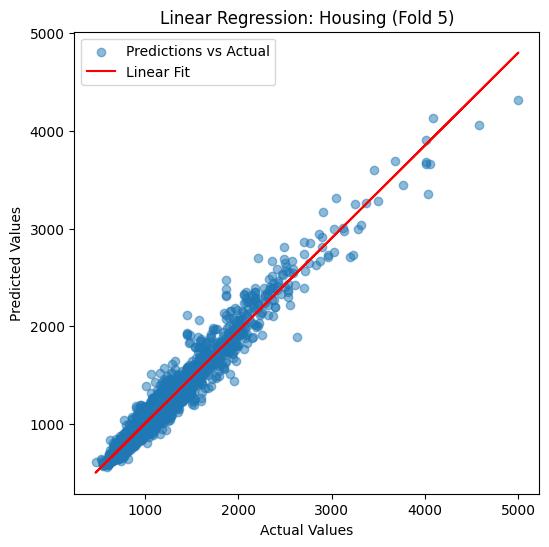

Model Results for Food (Fold 5):
Test Data: MAE: 31.0661, R-Squared: 0.9821, RMSE: 46.0547, MSE: 2121.0326 ,smape: 3.5248322355523665, mape: 3.5258
R^2 Score for Food: 0.9821


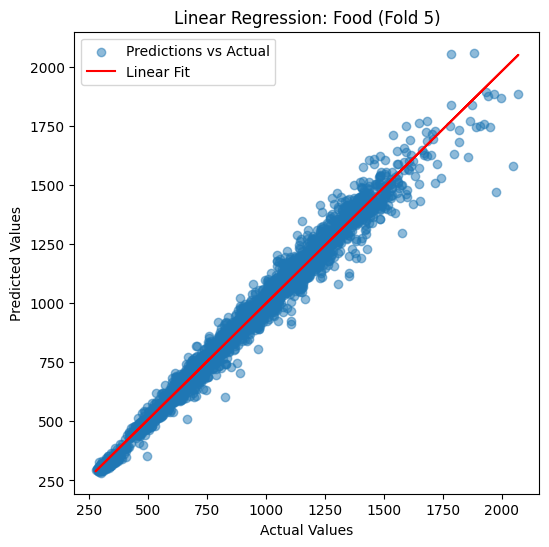

Model Results for Transportation (Fold 5):
Test Data: MAE: 64.567, R-Squared: 0.8582, RMSE: 90.7319, MSE: 8232.2854 ,smape: 4.1902085218146174, mape: 4.2806
R^2 Score for Transportation: 0.8592


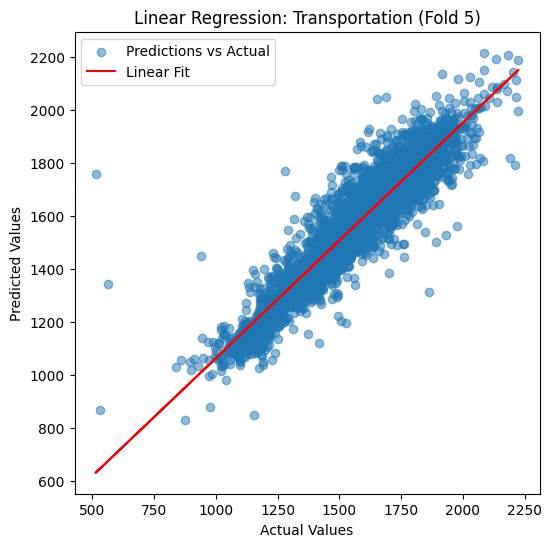

Model Results for Healthcare (Fold 5):
Test Data: MAE: 63.4898, R-Squared: 0.9661, RMSE: 93.9998, MSE: 8835.9622 ,smape: 4.961237157666984, mape: 4.9997
R^2 Score for Healthcare: 0.9661


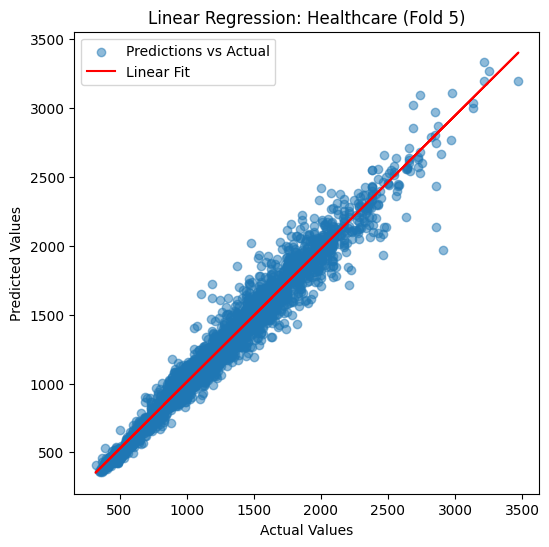

Model Results for Othernecessities (Fold 5):
Test Data: MAE: 23.0537, R-Squared: 0.9791, RMSE: 33.7471, MSE: 1138.8657 ,smape: 3.3389476604959096, mape: 3.3578
R^2 Score for Othernecessities: 0.9792


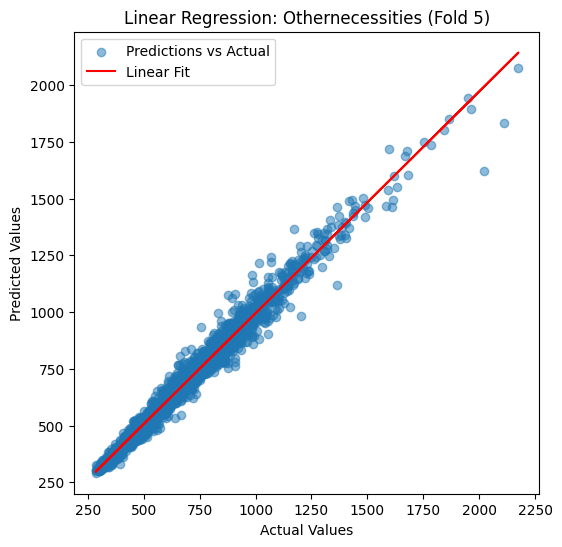

Model Results for Childcare (Fold 5):
Test Data: MAE: 64.6244, R-Squared: 0.9765, RMSE: 105.2561, MSE: 11078.8546 ,smape: 5.423391784655527, mape: 5.5406
R^2 Score for Childcare: 0.9767


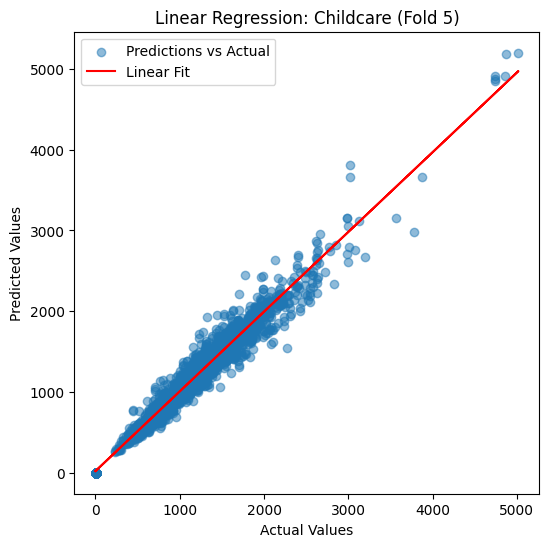

Model Results for Taxes (Fold 5):
Test Data: MAE: 22.1442, R-Squared: 0.9955, RMSE: 31.3155, MSE: 980.6598 ,smape: 2.2790950147994877, mape: 2.3145
R^2 Score for Taxes: 0.9966


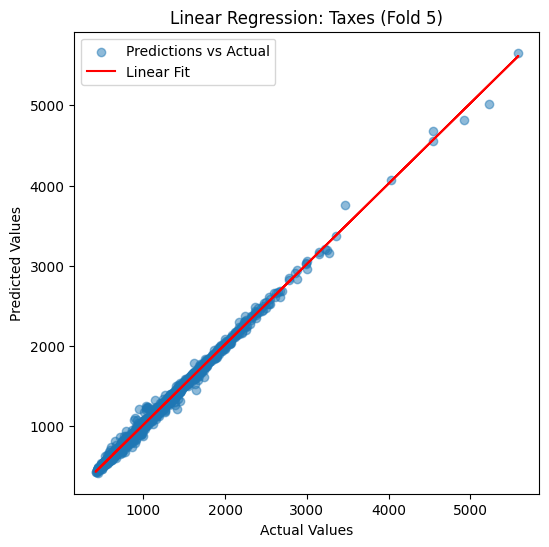

Test data has been saved to 'test_data.pkl'


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Cross-Validation with Evaluation and Linear Regression Plots
def cross_val_with_evaluation(X_scaled, y_exp_scaled, kf, num_epochs=200):
    fold = 1
    test_data_storage = []  # List to store test data for all folds

    for train_index, val_index in kf.split(X_scaled):
        print(f"Fold {fold}/{kf.get_n_splits()}")
        X_train, X_test_val = X_scaled[train_index], X_scaled[val_index]
        y_train, y_test_val = y_exp_scaled[train_index], y_exp_scaled[val_index]

        # Splitting test and validation sets
        X_test, X_val, y_test, y_val = train_test_split(X_test_val, y_test_val, test_size=0.5, random_state=100)

        # Reshaping data for CNN
        X_train = X_train[..., np.newaxis]
        X_val = X_val[..., np.newaxis]
        X_test = X_test[..., np.newaxis]

        # Create and compile model
        model = create_hybrid_model((X_train.shape[1], 1), y_train.shape[1])
        model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
        early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

        model.summary()

        # Training
        model.fit(X_train, [y_train[:, i] for i in range(y_train.shape[1])],
                  validation_data=(X_val, [y_val[:, i] for i in range(y_val.shape[1])]),
                  epochs=num_epochs, batch_size=64, verbose=1, callbacks=[early_stopping])

        # Predictions
        y_test_pred = np.column_stack(model.predict(X_test))

        # Inverse scaling
        y_test_pred_original = scaler_y.inverse_transform(y_test_pred)
        y_test_original = scaler_y.inverse_transform(y_test)

        # Enforce rule for childcare expense
        y_test_pred_original[:, childcare_exp_col] = np.where(
            X_test[:, num_children_col, 0] == 0, 0, y_test_pred_original[:, childcare_exp_col])

        # Store test data for this fold
        test_data = {
            "X_test": X_test,
            "y_test_original": y_test_original,
            "y_test_pred_original": y_test_pred_original
        }
        test_data_storage.append(test_data)

        # Metrics for each target
        for i, target in enumerate(target_col_list):
            print(f'Model Results for {target.capitalize()} (Fold {fold}):')
            print('Test Data:', regr_report(y_test_original[:, i], y_test_pred_original[:, i]))

            # Linear Regression Fit and Plot
            reg = LinearRegression()
            reg.fit(y_test_original[:, i].reshape(-1, 1), y_test_pred_original[:, i].reshape(-1, 1))
            y_pred_lr = reg.predict(y_test_original[:, i].reshape(-1, 1))

            r2 = r2_score(y_test_pred_original[:, i], y_pred_lr)
            print(f"R^2 Score for {target.capitalize()}: {r2:.4f}")

            plt.figure(figsize=(6, 6))
            plt.scatter(y_test_original[:, i], y_test_pred_original[:, i], alpha=0.5, label='Predictions vs Actual')
            plt.plot(y_test_original[:, i], y_pred_lr, color='red', label='Linear Fit')
            plt.xlabel('Actual Values')
            plt.ylabel('Predicted Values')
            plt.title(f'Linear Regression: {target.capitalize()} (Fold {fold})')
            plt.legend()
            plt.show()

        fold += 1

    # Save the test data to a file
    with open('test_data.pkl', 'wb') as f:
        pickle.dump(test_data_storage, f)

    print("Test data has been saved to 'test_data.pkl'")
    return model

# Example usage
model_combine = cross_val_with_evaluation(additional_features, y_exp_scaled, kf)
model_combine.save_weights("test_model_expenses.weights.h5")

## Secondary research contribution

**Model 2: TabNet Regressor with LIME and Counterfactual Explanation**

**Importing necessary libraries**

In [23]:
!pip install lime
!pip install dice-ml
!pip install pytorch_tabnet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=b1d3b3ddfeed7ad8d566de7d9ea1168eac77d505dbb156c93857f5d76adaddeb
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 42.6 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 1.5.3 which is incompatible.
mizani 0.13.1 requires

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 862.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 67.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

**Data preprocessing**

In [24]:
from sklearn.model_selection import train_test_split
y_expenses = household_dataset[['median_family_income','housing', 'food', 'transportation', 'healthcare', 'othernecessities', 'childcare', 'taxes']]
household_income_sufficiency = household_dataset[['financial_stability']].values

scaler_y_stability = MinMaxScaler()
household_income_sufficiency = scaler_y_stability.fit_transform(household_income_sufficiency)


# 80/10/10 split for TabNet
X_train_tabnet, X_rem, y_exp_train_tabnet, y_exp_rem, y_stab_train_tabnet, y_stab_rem = train_test_split(
    X, y_expenses, household_income_sufficiency, test_size=0.2, random_state=100)

X_test_tabnet, X_val_tabnet, y_exp_test_tabnet, y_exp_val_tabnet, y_stab_test_tabnet, y_stab_val_tabnet = train_test_split(
    X_rem, y_exp_rem, y_stab_rem, test_size=0.5, random_state=100)

**Model training**

In [25]:
# TabNet Model for Financial Stability Prediction
from pytorch_tabnet.tab_model import TabNetRegressor
tabnet_stab = TabNetRegressor()
tabnet_stab.fit(
    y_exp_train_tabnet.values, y_stab_train_tabnet.reshape(-1, 1),
    eval_set=[(y_exp_val_tabnet.values, y_stab_val_tabnet.reshape(-1, 1)), (y_exp_test_tabnet.values, y_stab_test_tabnet.reshape(-1, 1))],
    max_epochs=120,
    patience=10,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0
)

tabnet_stab.save_model("tabnet_stability.pth")

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.22362 | val_0_mse: 8.01884 | val_1_mse: 7.97779 |  0:00:05s
epoch 1  | loss: 0.00943 | val_0_mse: 0.17622 | val_1_mse: 0.18508 |  0:00:07s
epoch 2  | loss: 0.0054  | val_0_mse: 0.02902 | val_1_mse: 0.02677 |  0:00:09s
epoch 3  | loss: 0.00401 | val_0_mse: 0.01246 | val_1_mse: 0.01167 |  0:00:11s
epoch 4  | loss: 0.00327 | val_0_mse: 0.00778 | val_1_mse: 0.00757 |  0:00:12s
epoch 5  | loss: 0.00287 | val_0_mse: 0.00515 | val_1_mse: 0.00491 |  0:00:14s
epoch 6  | loss: 0.00264 | val_0_mse: 0.00306 | val_1_mse: 0.00291 |  0:00:15s
epoch 7  | loss: 0.0024  | val_0_mse: 0.00212 | val_1_mse: 0.00202 |  0:00:17s
epoch 8  | loss: 0.00238 | val_0_mse: 0.00167 | val_1_mse: 0.00156 |  0:00:19s
epoch 9  | loss: 0.00214 | val_0_mse: 0.00154 | val_1_mse: 0.00152 |  0:00:21s
epoch 10 | loss: 0.00186 | val_0_mse: 0.00125 | val_1_mse: 0.00117 |  0:00:22s
epoch 11 | loss: 0.00189 | val_0_mse: 0.00096 | val_1_mse: 0.00105 |  0:00:24s
epoch 12 | loss: 0.00177 | val_0_mse: 0.001   | val_

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Successfully saved model at tabnet_stability.pth.zip


'tabnet_stability.pth.zip'

**Model evaluation**

In [26]:
y_stab_pred_test = tabnet_stab.predict(y_exp_test_tabnet.values)

# Evaluation Function
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}



# Evaluate Results
stability_results = evaluate_model(y_stab_test_tabnet.reshape(-1, 1), y_stab_pred_test)

print("Test evaluation for the tabnetregressor:", stability_results)

Test evaluation for the tabnetregressor: {'MAE': 0.009322637811815783, 'MSE': 0.00016384195347504427, 'RMSE': np.float64(0.012800076307391463), 'R2': 0.9891231562718139, 'MAPE': np.float64(inf)}


<ipython-input-8-bf3b6529f734>:3: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


**Test the predictions**

In [27]:
# Rescale predictions back to original scale
y_stab_pred_test_rescaled = scaler_y_stability.inverse_transform(y_stab_pred_test)
y_stab_test_rescaled = scaler_y_stability.inverse_transform(y_stab_test_tabnet)

# Print Predictions and Actual Values
print("Predicted Financial Stability (Test Set):", y_stab_pred_test_rescaled.flatten())
print("Actual Financial Stability (Test Set):", y_stab_test_rescaled.flatten())

Predicted Financial Stability (Test Set): [1.1682718  1.1839374  0.7311708  ... 1.7847284  0.8284409  0.62181103]
Actual Financial Stability (Test Set): [1.16865333 1.19489796 0.73943864 ... 1.78444539 0.85570743 0.6409312 ]


**XAI Technique: LIME**

In [28]:
# LIME for Explainability
from lime.lime_tabular import LimeTabularExplainer
explainer = LimeTabularExplainer(
    training_data=y_exp_train_tabnet.values,
    feature_names=y_exp_train_tabnet.columns.tolist(),
    class_names=y_exp_train_tabnet.columns.tolist(),
    mode='regression'
)

data_row = [5227.250000,864, 584, 1339, 791, 513,0,661]

data_row = np.array(data_row) # This line is added to convert the list into a numpy array
exp = explainer.explain_instance(
    data_row=data_row,  # Use 1D data here
    predict_fn=tabnet_stab.predict
)


# Display Explanation
print("\nLIME Explanation:")


# # Plot Explanation
exp.show_in_notebook(show_table=True)


LIME Explanation:


**XAI Technique 2: Counterfactual Explanation**

In [29]:
counterfactual_input_cols = ['median_family_income','housing', 'food', 'transportation', 'healthcare', 'othernecessities', 'childcare', 'taxes','financial_stability']

In [30]:
y_exp_test_tabnet

,median_family_income,housing,food,transportation,healthcare,othernecessities,childcare,taxes
11365,5490.333333,690,593,1235,1114,432,0,634
24745,5562.250000,761,646,1288,950,473,0,536
9849,6867.166667,1151,1377,1808,1974,850,990,1137
4662,6067.750000,1156,733,1746,1124,635,757,974
27282,6543.333333,1369,652,1604,975,680,1317,797
...,...,...,...,...,...,...,...,...
7845,9380.416667,922,589,1343,827,508,0,684
20958,9414.833333,1557,1373,1697,1549,986,2065,1389
27050,6311.583333,795,296,1130,479,367,0,470
11457,7543.916667,1263,959,1695,1677,748,1350,1123


In [31]:
new_test_with_indicator= y_exp_test_tabnet.copy()
new_test_with_indicator["financial_stability"] = y_stab_test_tabnet

In [32]:
new_test_with_indicator

,median_family_income,housing,food,transportation,healthcare,othernecessities,childcare,taxes,financial_stability
11365,5490.333333,690,593,1235,1114,432,0,634,0.362097
24745,5562.250000,761,646,1288,950,473,0,536,0.370228
9849,6867.166667,1151,1377,1808,1974,850,990,1137,0.229108
4662,6067.750000,1156,733,1746,1124,635,757,974,0.263828
27282,6543.333333,1369,652,1604,975,680,1317,797,0.274231
...,...,...,...,...,...,...,...,...,...
7845,9380.416667,922,589,1343,827,508,0,684,0.596315
20958,9414.833333,1557,1373,1697,1549,986,2065,1389,0.274783
27050,6311.583333,795,296,1130,479,367,0,470,0.552894
11457,7543.916667,1263,959,1695,1677,748,1350,1123,0.265133


In [33]:
continuous_features=counterfactual_input_cols
outcome_name='financial_stability'

query_instance = pd.DataFrame(
              [data_row],
              columns=counterfactual_input_cols[:-1]
        )

In [34]:
from dice_ml import Data, Model as Modeldice
import dice_ml
# Initialize DiCE for Counterfactual Explanations
data_dice = dice_ml.Data(
    dataframe=new_test_with_indicator,
    continuous_features=y_exp_test_tabnet.columns.tolist(),
    outcome_name='financial_stability'
)


# Wrap the TabNet Stability Model for DiCE
class TabNetWrapper:
    def __init__(self, model):
        self.model = model

    def predict(self, input_data):
        input_data = np.array(input_data)
        return self.model.predict(input_data)

dice_model = Modeldice(model=TabNetWrapper(tabnet_stab), backend="sklearn",  model_type='regressor')

# Generate Counterfactuals
# query_instance = y_exp_test_tabnet.iloc[[0]][y_exp_train_tabnet.columns.tolist()]
counterfactuals = dice_ml.Dice(data_dice, dice_model, method="random")

# Generate 3 diverse counterfactuals
cf = counterfactuals.generate_counterfactuals(query_instance,
                                              total_CFs=3,
                                              desired_range=[0.6, 1.0])  # Desired stability range

# Display Counterfactuals
print("\nCounterfactual Explanations:")
cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  2.66it/s]


Counterfactual Explanations:
Query instance (original outcome : 0.0)


,median_family_income,housing,food,transportation,healthcare,othernecessities,childcare,taxes,financial_stability
0,5227.25,864.0,584.0,1339.0,791.0,513.0,0.0,661.0,0.0



Diverse Counterfactual set (new outcome: [0.6, 1.0])


,median_family_income,housing,food,transportation,healthcare,othernecessities,childcare,taxes,financial_stability
0,14953.6,1487.0,-,-,-,-,-,-,0.8196287155151367
1,12231.3,-,-,1670.0,-,-,-,-,0.6748877763748169
2,12047.4,-,-,-,-,-,-,-,0.7164760828018188
